# Практична робота 2. Дерева рішень за допомогою Scikit-Learn

Scikit-Learn (він же sklearn) — проста та добре розроблена бібліотека машинного навчання.

Scikit-Learn надає різні алгоритми навчання. Користуватися ними так само просто, як наповнити чашку кави.

Окрім алгоритмів навчання, бібліотека також надає функції обробки даних, які також дуже прості у використанні. На додаток до цих функцій обробки, Scikit-Learn пропонує інші функції, такі як конвеєри, налаштування моделі та багато іншого.

Основні матеріали для цього курсу створено за допомогою блокнотів Jupyter.
Це дозволяє вставити код виконання безпосередньо в матеріал лабораторних робіт та використовувати його для демонстрації алгоритмів
Щоб запускати та редагувати код, збережіть копію цього ноутбука собі (File->Save a copy in Drive...). Свою копію ви зможете змінювати та запускати


# Що ви дізнаєтеся з практичної роботи?
*   Дерева рішень для класификації
*   Дерева рішень для регресії
*   Випадкові ліси

Не забуваємо про виконання індивідуального завдання наприкінці документу

# Програмне забезпечення, яке ми будемо використовувати

Ми будемо використовувати Python і популярні бібліотеки для завдань машинного навчання, такі як:
*   **scikit-learn** - вона реалізує більшість класичних алгоритмів машинного навчання
*   **numpy, pandas** - лінійна алгебра та бібліотеки обробки даних, які використовуються для реалізації алгоритмів з нуля

<a name='0'></a>
# Дерева рішень - вступ

Дерева рішень — це керовані алгоритми машинного навчання, які використовуються як для завдань регресії, так і для класифікації. Дерева — це потужні алгоритми, які можуть обробляти складні набори даних.

У цій частині ми навчимось прогнозувати безперервні значення за допомогою дерев рішень (регресії).

На відміну від інших алгоритмів, тут є дві речі, які дуже важливі для дерев:

Ось 7 цікавих фактів про дерева рішень:

* Їм не потрібні числові вхідні дані для масштабування. Якими б не були числові значення, дерева рішень не мають значення.

* Дерева рішень обробляють категоричні характеристики у форматі необробленого тексту (Scikit-Learn не підтримує це, реалізація дерев TensorFlow підтримує).

* На відміну від інших складних алгоритмів навчання, результати дерев рішень можна інтерпретувати. Справедливо сказати, що дерева рішень не є моделями типу чорної скриньки.
* Хоча більшість моделей страждатимуть від відсутності значень, у дерев рішень з цим все добре.
* Дерева можуть обробляти незбалансовані набори даних. Вам залишиться лише налаштувати ваги класів.
* Дерева можуть надати важливість ознак або те, наскільки кожна ознака внесла результати в навчання моделі.
* Дерева є основними будівельними блоками методів ансамблю, таких як random forests та gradient boosting machines.

Те, як працюють дерева рішень, схоже на серію запитань if/else. Припустимо, ви хочете прийняти рішення про покупку автомобіля. Щоб придбати потрібний автомобіль, ви можете продовжити й оцінити рівень безпеки, кількість сидінь і дверей, поставивши серію схожих запитань.

Ось структура дерев рішень.

![Decision Trees.png](https://cdn.hashnode.com/res/hashnode/image/upload/v1632212349927/4XijLSXib.png)


Добре відомим недоліком дерев рішень є те, що вони легко перенавчаються. Один із способів подолання надмірного перенавчання — зменшити максимальну глибину дерева рішень (іменовану гіперпараметром `max_depth`) у деревах рішень. Ми побачимо інші методи, щоб уникнути перенавчання.

Подивимось на компоненти задачі керованого машинного навчання або навчання з вчителем

На високому рівні проблема керованого машинного навчання має таку структуру:

$$ \underbrace{\text{Training Dataset}}_\text{Attributes + Features} + \underbrace{\text{Learning Algorithm}}_\text{Model Class + Objective + Optimizer } \to \text{Predictive Model} $$

Для того щоб зрозуміти, що таке дерева рішень розглянемо приклад
Ми будемо використовувати набір даних про діабет UCI.
Для кожного пацієнта ми маємо доступ до вимірювання його індексу маси тіла (ІМТ) і кількісної оцінки ризику діабету (від 0 до 400).
Нам цікаво зрозуміти, як ІМТ впливає на ризик діабету в окремої людини.

Почнемо із завантаження цього набору даних.


In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [12, 4]
from sklearn import datasets

# Завантажемо diabetes dataset
diabetes = datasets.load_diabetes(as_frame=True)
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

Ми також можемо безпосередньо переглядати дані

In [ ]:
# diabetes dataset
diabetes_X, diabetes_y = diabetes.data, diabetes.target

# створити ознаку бінарного ризику
diabetes_y_risk = diabetes_y.copy()
diabetes_y_risk[:] = 0
diabetes_y_risk[diabetes_y > 150] = 1

# Виведемо частину даних
diabetes_X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## Дерева рішень: інтуїція

Дерева прийняття рішень – це моделі машинного навчання, які імітують те, як людина підійде до цієї проблеми.

Ми починаємо з вибору ознаки (наприклад, віку).

Потім ми розгалужуємось за ознакою на основі її значення (наприклад, вік > 65?).

Ми вибираємо та розгалужуємось за однією чи декількома ознаками (наприклад, це чоловік?)

Потім ми повертаємо результат, який залежить від усіх характеристик, які ми бачили (наприклад, чоловік старше 65 років)

## Дерева рішень: приклад

Давайте спочатку розглянемо приклад набору даних про діабет.

Ми навчимо дерево рішень, використовуючи його реалізацію в sklearn.

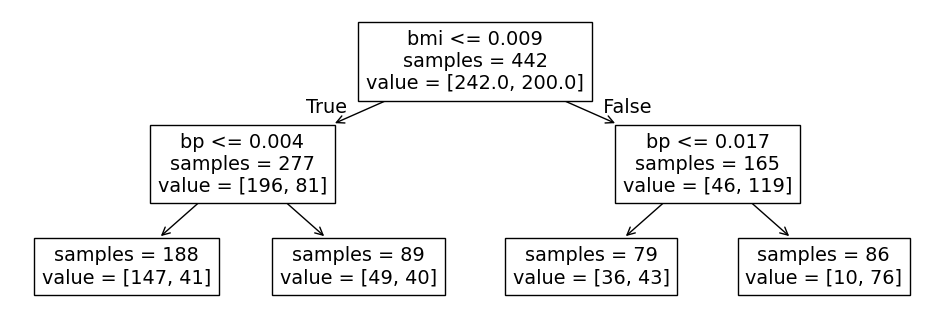

In [ ]:
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# create and fit the model
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(diabetes_X.iloc[:,:4], diabetes_y_risk)

# visualize the model
plot_tree(clf, feature_names=diabetes_X.columns[:4], impurity=False)
print('')

## Правила прийняття рішень

Давайте тепер визначимо дерево рішень трохи більш формально. Перша важлива концепція — це правило.

* Правило прийняття рішень $r : \mathcal{X} \to \{\text{true}, \text{false}\}$ це поділ простору ознак на дві непересічні області, наприклад:
$$ r(x) = \begin{cases}\text{true} & \text{if } x_\text{bmi} \leq 0.009 \\ \text{false} & \text{if } x_\text{bmi} > 0.009 \end{cases} $$
* Зазвичай правило застосовується лише до однієї ознаки чи атрибута $x_j$ of $x$.
* Якщо $x_j$ є неперервним, правило зазвичай розділяє входи $x_j$ на непересічні проміжки $-\infty, c], (c, \infty)$.

## Область прийняття рішень

Наступна важлива концепція — це область прийняття рішень.
* Область прийняття рішень $R\subseteq \mathcal{X}$ це підмножина простору ознак, визначена застосуванням набору правил $r_1, r_2, \ldots, r_m$ та їх значення $v_1, v_2, \ldots, v_m \in \{\text{true}, \text{false}\}$, наприклад:
$$ R = \{x \in \mathcal{X} \mid r_1(x) = v_1 \text{ and } \ldots \text{ and } r_m(x) = v_m \} $$
* Наприклад, область вирішення проблеми діабету:
$$ R = \{x \in \mathcal{X} \mid x_\text{bmi} \leq 0.009 \text{ and } x_\text{bp} > 0.004 \} $$

## Дерева рішень: визначення

Дерево рішень є моделлю $f : \mathcal{X} \to \mathcal{Y}$ вигляду
$$ f(x) = \sum_{R \in \mathcal{R}} y_R \mathbb{I}\{x \in R\}. $$
* $\mathbb{I}\{\cdot\}$ є індикаторною функцією (один якщо $\{\cdot\}$ вірно, інакше нуль) і значення $y_R \in \mathcal{Y}$ є результатами для цьєї області.
* Множина $\mathcal{R}$ це сукупність областей прийняття рішень. Їх отримують шляхом *рекурсивне двійкове розщеплення (recursive binary splitting)*.
* Правила визначення областей $\mathcal{R}$ можна організувати у вигляді дерева з одним правилом на внутрішній вузол і областями, які є листками.

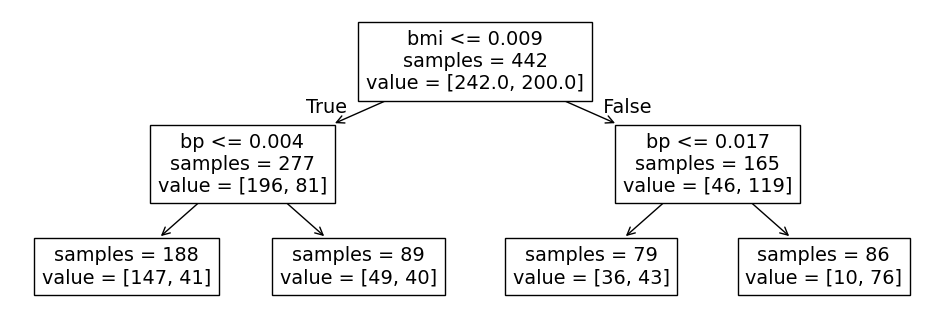

In [ ]:
plot_tree(clf, feature_names=diabetes_X.columns[:4], impurity=False)
print('')

Ми також можемо проілюструвати дерева рішень за допомогою цього малюнка

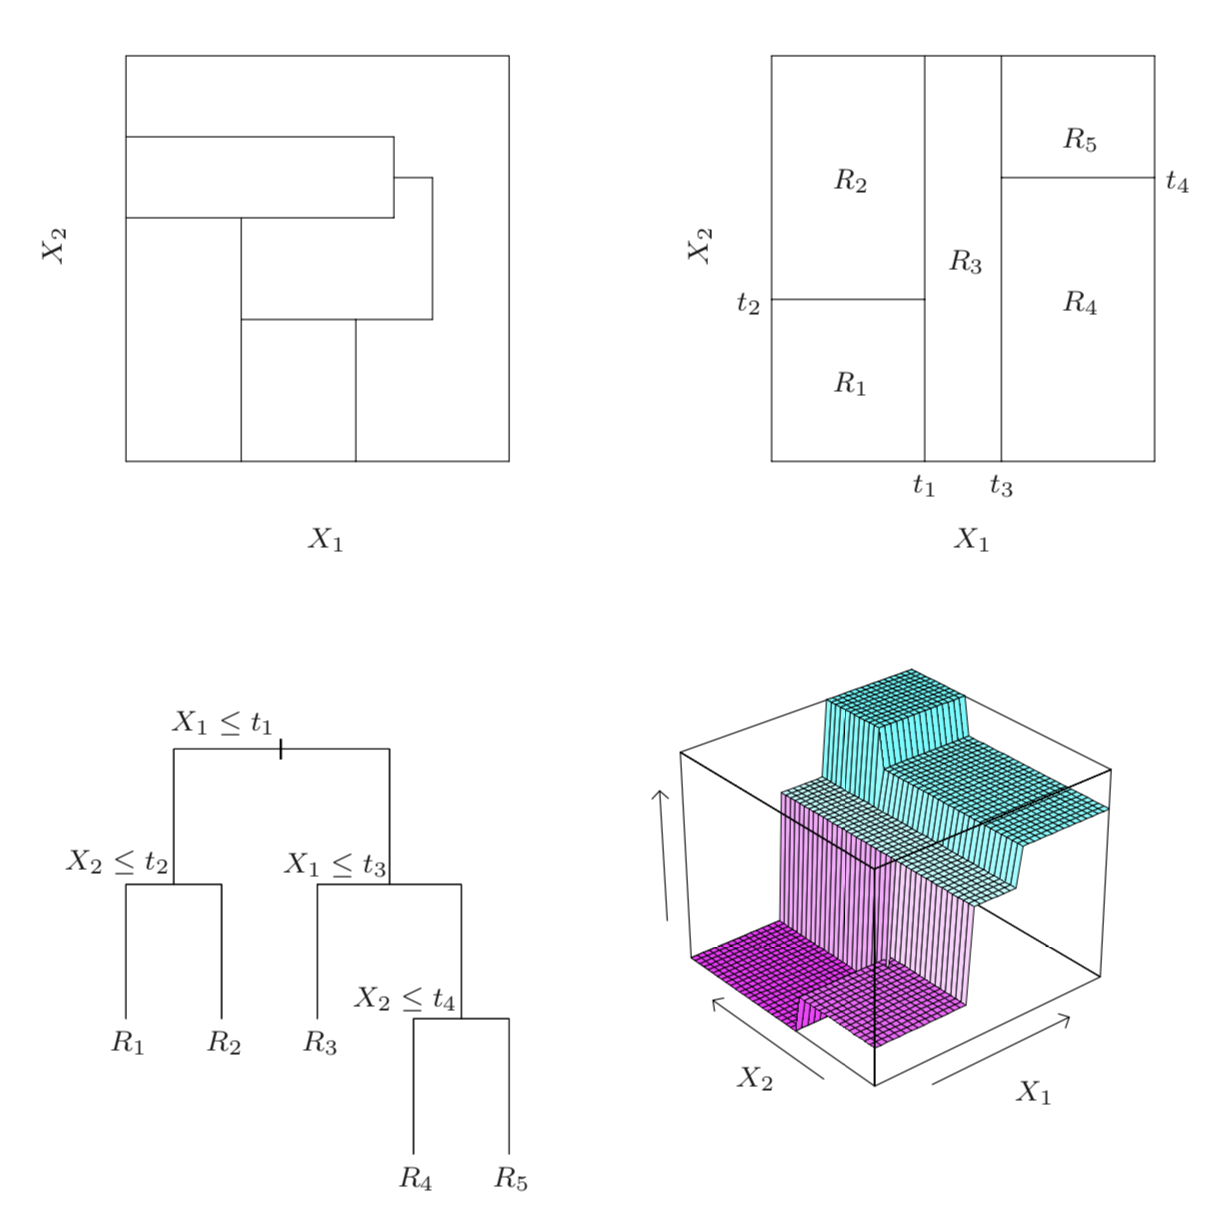

Ілюстрації показує:

Ліворуч угорі: регіони, які не можуть бути представлені деревом
Праворуч угорі: регіони, які можна представити деревом
Внизу ліворуч: дерево, що створює верхню праву область
Справа внизу: значення функцій, призначені регіонам

Ще раз акцентуємо, що дерева рішень є важливими моделями машинного навчання

Вони добре інтерпретуються.
Потрібна невелика підготовка даних (без масштабування, обробка безперервних і дискретних функцій).
Основні їх недоліки полягають у тому, що:
* Якщо вони залишаються маленькими та доступними для тлумачення, вони не такі потужні.
* Якщо вони великі, їх легко перенавчити, і їх важко врегулювати.

## Начання дерев рішень

На високому рівні дерева рішень формуються шляхом додавання вузлів по одному.

```python
def build_tree(tree, data):
    whlie tree.is_complete() is False:
        region, region_data = tree.get_region()
        new_rule = split_region(region_data)
        tree.add_rule(region, new_rule)
```

Найчастіше ми будуємо дерево, поки воно не досягне максимальної кількості вузлів. Суть алгоритму в `split_region`.

Існує також рекурсивне формулювання цього алгоритму:

```python
def build_tree(data, depth):
    if depth < MAX_DEPTH:
        # internal node
        rule, data_left, data_right = get_new_rule(tree, data)
        left_subtree = build_tree(data_left, depth+1)
        right_subtree = build_tree(data_right, depth+1)
        return create_node(new_rule, left_subtree, right_subtree)
    else:
        # leaf node
        return create_terminal_node(data)
```

## Вивчення нових правил прийняття рішень

Як функція `split_region` вибирає нове правило $r$? Дано набір даних $\mathcal{D} = \{(x^{(i)}, y^{(i)}\mid i =1,2,\ldots,n\}$, ми жадібно обираємо правило, яке забезпечує розділення набору даних із найменшими можливими втратами.

Це можна записати як таку задачу оптимізації:
$$ \min_{r \in \mathcal{U}} \left( \underbrace{L(\{(x, y) \in \mathcal{D} \mid r(x) = \text{T}\})}_\text{left subtree} +  \underbrace{L(\{(x, y) \in \mathcal{D} \mid r(x) = \text{F}\}}_\text{right subtree})\right) $$

де $L$ є функцією втрат над підмножиною даних, позначених правилом та $\mathcal{U}$ це набір можливих правил.

Який набір можливих правил? Коли $x$ має неперервні ознаки, правила мають такий вигляд:
$$ r(x) = \begin{cases}\text{true} & \text{if } x_j \leq t \\ \text{false} & \text{if } x_j > t \end{cases} $$
для індексу ознаки $j$ і порігу $t \in \mathbb{R}$.

Якщо $x$ має категоріальні ознаки, правила можуть мати такий вигляд:
$$ r(x) = \begin{cases}\text{true} & \text{if } x_j = t_k \\ \text{false} & \text{if } x_j \neq t_k \end{cases} $$
для індексу ознаки $j$ і можливого значення $t_k$ для $x_j$.

## Цілі для дерев: регресія

Які функції втрат ми можемо використовувати? У регресії зазвичай мінімізують помилку L2 між даними та єдиним найкращим прогнозом, який ми можемо зробити на цих даних:

$$ L(\mathcal{D}) = \sum_{(x, y) \in \mathcal{D}} \left( y - \texttt{average-y}(\mathcal{D}) \right)^2. $$

Якби це був листовий вузол, ми б передбачили $\texttt{average-y}(\mathcal{D})$, середнє значення $y$ у даних. Наведені вище втрати вимірюють результуючу квадратичну помилку.

Це призводить до наступної задачі оптимізації для вибору правила прийняття рішення:
$$ \min_{r \in \mathcal{U}} \sum_{(x, y) \in \mathcal{D} \,\mid\, r(x) = \text{true}} \left( y - p_\text{true}(r) \right)^2 +  \sum_{(x, y) \in \mathcal{D} \,\mid\, r(x) = \text{false}} \left( y - p_\text{false}(r) \right)^2 $$

де $p_\text{true}(r) = \texttt{average-y}(\{(x, y) \mid (x, y) \in \mathcal{D} \text{ and } r(x) = \text{true}\})$ та $p_\text{false}(r) = \texttt{average-y}(\{(x, y) \mid (x, y) \in \mathcal{D} \text{ and } r(x) = \text{false}\})$ є середніми прогнозами для кожної частини розділення даних.

## Цілі для дерев: класифікація

У класифікації ми можемо так само використовувати коефіцієнт помилкової класифікації
$$ L(\mathcal{D}) = \sum_{(x, y) \in \mathcal{D}} \mathbb{I} \left\{ y = \texttt{most-common-y}(\mathcal{D}) \right\}. $$

Якби це був листовий вузол, ми б передбачили $\texttt{most-common-y}(\mathcal{D})$, найпоширеніший клас $y$ у даних. Вищевказані втрати вимірюють отриману помилку неправильної класифікації.

Інші втрати, які можна використовувати, включають ентропію або індекс Джині. Усе це оптимізує розподіл, у якому різні класи не змішуються.

## Інші практичні міркування

Кілька додаткових коментарів до описаної вище процедури навчання:
* Вузли додаються, доки дерево не досягне максимальної глибини або листя більше не можна розділити.
* На практиці дерева також часто обрізають, щоб зменшити переначання.
* Існують альтернативні алгоритми, включаючи ID3, C4.5, C5.0. Дивись лекції за курсом для більшої інформації.

## Алгоритм: дерева класифікації та регресії (CART)
Частіще всього використовується.

Тип: контрольоване навчання (регресія та класифікація).

Модельне сімейство: Дерева рішень.

Цільова функція: помилка в квадраті, помилка неправильної класифікації, індекс Джіні тощо.

Оптимізатор: жадібне додавання правил з подальшим обрізанням.

Розглядається у лекціях за курсом

## Покращення алгоритмів машинного навчання

Далі ми розглянемо загальну методику покращення продуктивності алгоритмів машинного навчання.

Потім ми застосуємо його до дерев рішень, щоб визначити вдосконалений алгоритм.

Бутстреп-агрегування або бегінг, це метаалгоритм композиційного машинного навчання, призначений для покращення стабільності та точності алгоритмів машинного навчання, що використовуються в статистичній класифікації та регресії

## Перенавчання

Переначання є одним із найпоширеніших проблем у машинному навчанні.
* Дуже виразна модель (поліном високого ступеня) ідеально відповідає навчальному набору даних.
* Модель також робить надзвичайно неправильні прогнози за межами цього набору даних і не узагальнює.

Роглянемо приклад, у якому ми беремо випадкові вибірки навколо справжньої функції.

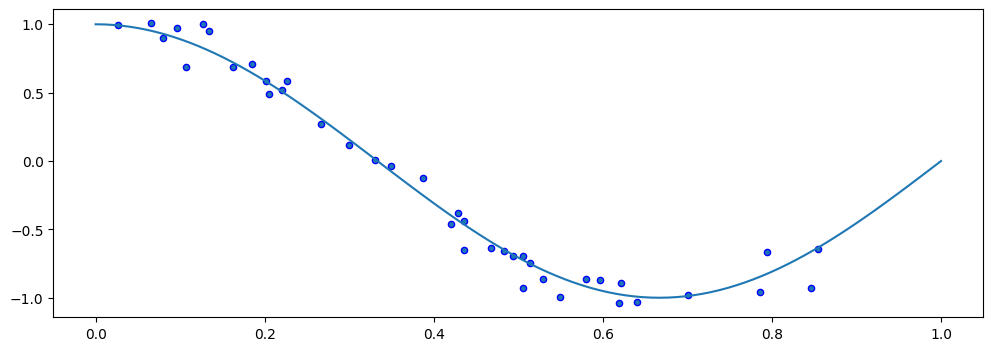

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def true_fn(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(2)
n_samples = 40
X = np.sort(np.random.rand(n_samples))
y = true_fn(X) + np.random.randn(n_samples) * 0.1

X_test = np.linspace(0, 1, 100)
plt.plot(X_test, true_fn(X_test), label="True function")
plt.scatter(X, y, edgecolor='b', s=20, label="Samples")

## Підгонка поліномів високого ступеня

Давайте подивимося, що станеться, якщо підібрати поліном високого ступеня до випадкових вибірок із 20 точок із цього набору даних.

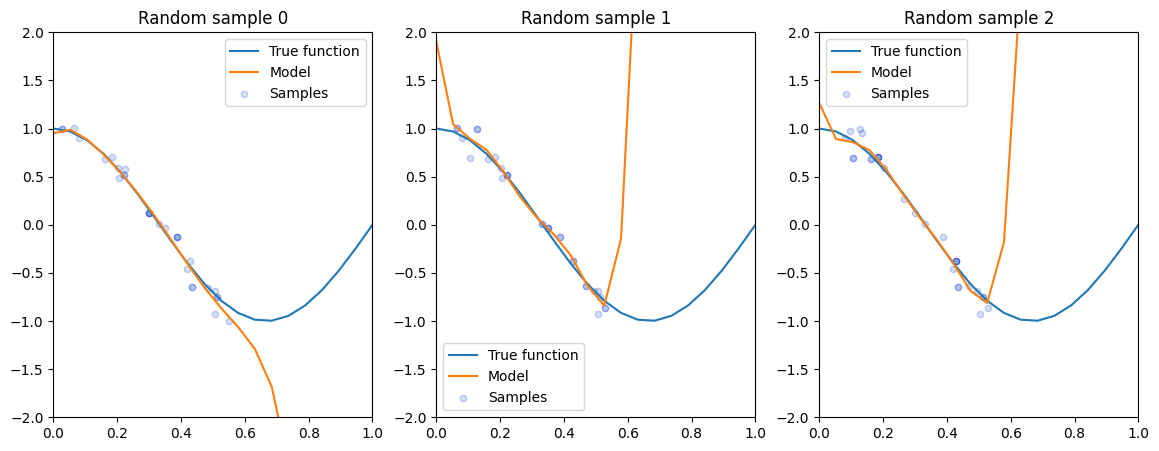

In [ ]:
n_plots, X_line = 3, np.linspace(0,1,20)
plt.figure(figsize=(14, 5))
for i in range(n_plots):
    ax = plt.subplot(1, n_plots, i + 1)
    random_idx = np.random.randint(0, 30, size=(30,))
    X_random, y_random = X[random_idx], y[random_idx]

    polynomial_features = PolynomialFeatures(degree=6, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X_random[:, np.newaxis], y_random)

    ax.plot(X_line, true_fn(X_line), label="True function")
    ax.plot(X_line, pipeline.predict(X_line[:, np.newaxis]), label="Model")
    ax.scatter(X_random, y_random, edgecolor='b', s=20, label="Samples", alpha=0.2)
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title('Random sample %d' % i)

## Високоваріаційні моделі

Кожен невеликий набір даних, які ми тренуємо на основі результатів, є зовсім іншою моделлю.

Алгоритм, який має тенденцію до перепідбору, також називається *високодисперсійним*, оскільки він виводить прогностичну модель, яка сильно змінюється, якщо ми трохи порушуємо набір даних.

## Бегінг: агрегація Bootstrap

Ідея *бегинга* полягає в тому, щоб зменшити дисперсію моделі шляхом усереднення багатьох моделей, навчених на випадкових підмножинах даних.

```python
for i in range(n_models):
    # collect data samples and fit models
    X_i, y_i = sample_with_replacement(X, y, n_samples)
    model = Model().fit(X_i, y_i)
    ensemble.append(model)

# output average prediction at test time:
y_test = ensemble.average_prediction(x_test)
```
Зразки даних беруться із заміною та відомі як початкові зразки.

## Поліноміальна регресія

Давайте застосуємо бегінг до нашої задачі поліноміальної регресії.

Ми збираємося навчити велику кількість поліноміальних регресій на випадкових підмножинах набору даних точок, які ми створили раніше.

Почнемо з підготовки ансамблю моделей для бегінгу.

In [ ]:
n_models, n_subset = 10000, 30
ensemble, Xs, ys = [], [], []
for i in range(n_models):
    # take a random subset of the data
    random_idx = np.random.randint(0, 30, size=(n_subset,))
    X_random, y_random = X[random_idx], y[random_idx]

    # train a polynomial regression model
    polynomial_features = PolynomialFeatures(degree=6, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("pf", polynomial_features), ("lr", linear_regression)])
    pipeline.fit(X_random[:, np.newaxis], y_random)

    # add it to our set of bagged models
    ensemble += [pipeline]
    Xs += [X_random]
    ys += [y_random]

Давайте візуалізуємо передбачення пакетної моделі на кожній випадковій вибірці набору даних і порівняємо з передбаченнями моделей без бегінгу.

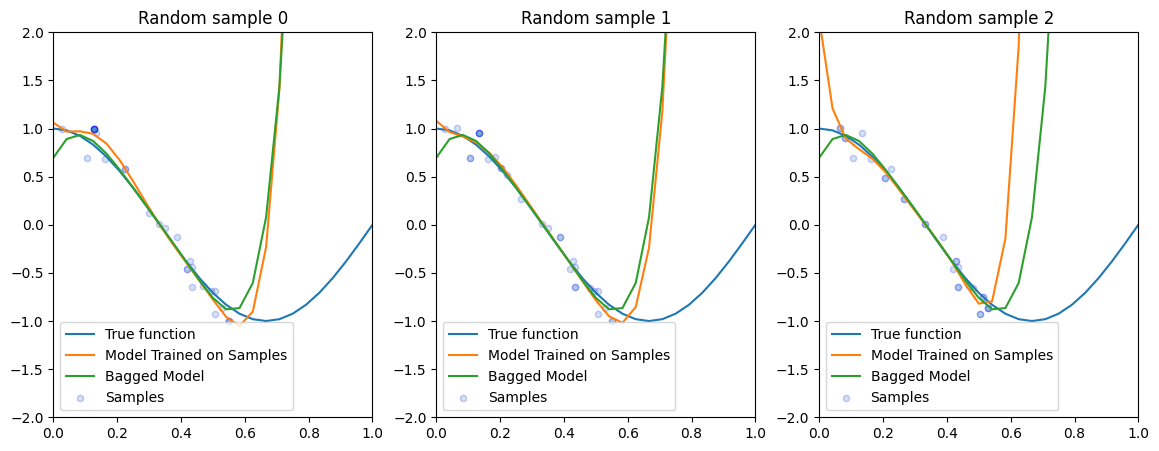

In [ ]:
n_plots, X_line = 3, np.linspace(0,1,25)
plt.figure(figsize=(14, 5))
for i in range(n_plots):
    ax = plt.subplot(1, n_plots, i + 1)

    # generate average predictions
    y_lines = np.zeros((25, n_models))
    for j, model in enumerate(ensemble):
        y_lines[:, j] = model.predict(X_line[:, np.newaxis])
    y_line = y_lines.mean(axis=1)

    # visualize them
    ax.plot(X_line, true_fn(X_line), label="True function")
    ax.plot(X_line, y_lines[:,i], label="Model Trained on Samples")
    ax.plot(X_line, y_line, label="Bagged Model")
    ax.scatter(Xs[i], ys[i], edgecolor='b', s=20, label="Samples", alpha=0.2)
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="best")
    ax.set_title('Random sample %d' % i)

## Розширення бегінгу

Існує кілька технік, тісно пов’язаних із бегінгом.
* Коли беруться проби без заміни.
* Випадкові функції – це випадкова вибірка функцій.
* Випадкове виправлення — це коли ми робимо обидві вищезгадані дії.

## Резюме: бегінг

Бегінг – це загальна техніка, яку можна використовувати з високоваріантними алгоритмами ML.
Він усереднює прогнози з кількох моделей, навчених на випадковій підмножині даних.

Пізніше ще ми поговоримо про випадковий ліс

Повернемось до розгляду дерев рішень в завданнях регресії та класифікації

# Дерева рішень для регресії

* 1 - Імпорт
* 2 - Завантаження даних
* 3 - Дослідницький аналіз
* 4 - Попередня обробка даних
* 5 - Навчання дерева рішень
* 6 - Оцінка дерев рішень
* 7 - Покращення дерев рішень

<a name='1'></a>
### 1 - Імпорт

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

<a name='2'></a>

### 2 - Завантаження даних

У цьому завданні регресії з деревами рішень ми будемо використовувати набір даних центрального процесора, доступний в  [OpenML](https://www.openml.org/t/5492). Ми завантажимо його за допомогою функції Sklearn - `fetch_openml`.

Ми передбачимо відносну продуктивність ЦП за такими даними:

* MYCT: час машинного циклу в наносекундах (integer)
* MMIN: мінімальна основна пам'ять у кілобайтах (integer)
* MMAX: максимальна основна пам'ять у кілобайтах (integer)
* CACH: кеш-пам'ять у кілобайтах (integer)
* CHMIN: мінімальна кількість каналів в одиницях (integer)
* CHMAX: максимальна кількість каналів в одиницях (integer)
* PRP: відносна ефективність(integer) (цільова змінна)

In [ ]:
# Давайте приховаємо попередження

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.datasets import fetch_openml

machine_cpu = fetch_openml(name='machine_cpu')

In [ ]:
type(machine_cpu)

sklearn.utils._bunch.Bunch

In [ ]:
machine_cpu.data.shape

(209, 6)

In [ ]:
print(machine_cpu.DESCR)

**Author**:   
**Source**: Unknown -   
**Please cite**:   

The problem concerns Relative CPU Performance Data. More information can be obtained in the UCI Machine
 Learning repository (http://www.ics.uci.edu/~mlearn/MLSummary.html).
 The used attributes are :
 MYCT: machine cycle time in nanoseconds (integer)
 MMIN: minimum main memory in kilobytes (integer)
 MMAX: maximum main memory in kilobytes (integer)
 CACH: cache memory in kilobytes (integer)
 CHMIN: minimum channels in units (integer)
 CHMAX: maximum channels in units (integer)
 PRP: published relative performance (integer) (target variable)
 
 Original source: UCI machine learning repository. 
 Source: collection of regression datasets by Luis Torgo (ltorgo@ncc.up.pt) at
 http://www.ncc.up.pt/~ltorgo/Regression/DataSets.html
 Characteristics: 209 cases; 6 continuous variables

Downloaded from openml.org.


In [ ]:
# Відображення назв ознак

machine_cpu.feature_names

['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX']

In [ ]:
# Отримання всього кадру даних

machine_cpu.frame

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,class
0,125,256,6000,256,16,128,198
1,29,8000,32000,32,8,32,269
2,29,8000,32000,32,8,32,220
3,29,8000,32000,32,8,32,172
4,29,8000,16000,32,8,16,132
...,...,...,...,...,...,...,...
204,124,1000,8000,0,1,8,42
205,98,1000,8000,32,2,8,46
206,125,2000,8000,0,2,14,52
207,480,512,8000,32,0,0,67


Тепер візьмемо дані та мітки

In [ ]:
machine_data = machine_cpu.data
machine_labels = machine_cpu.target

In [ ]:
type(machine_data)

pandas.core.frame.DataFrame

In [ ]:
type(machine_labels)

pandas.core.series.Series

<a name='3'></a>
### 3 - Дослідницький аналіз

```
# Выбран кодовый формат
```




Перш ніж проводити аналіз, давайте отримаємо навчальні та тестові дані

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(machine_data,machine_labels, test_size=0.2,random_state=20)

print('Розмір навчальних даних: {} \n Розмір тестових даних: {}'.format(len(X_train), len(X_test)))

Розмір навчальних даних: 167 
 Розмір тестових даних: 42


Давайте візуалізуємо гістограми всіх числових ознак

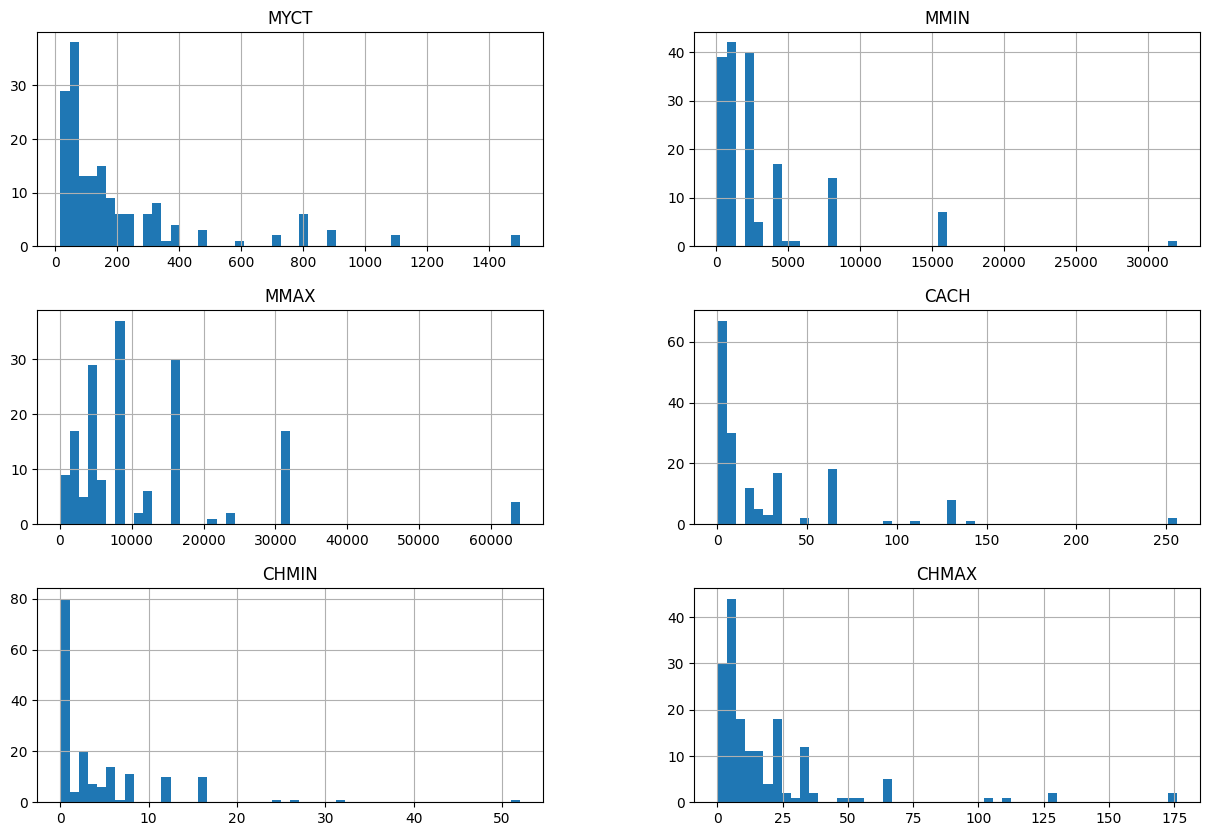

In [ ]:
X_train.hist(bins=50, figsize=(15,10))
plt.show()

Або ми можемо використовувати `sns.pairplot()` для перегляду даних

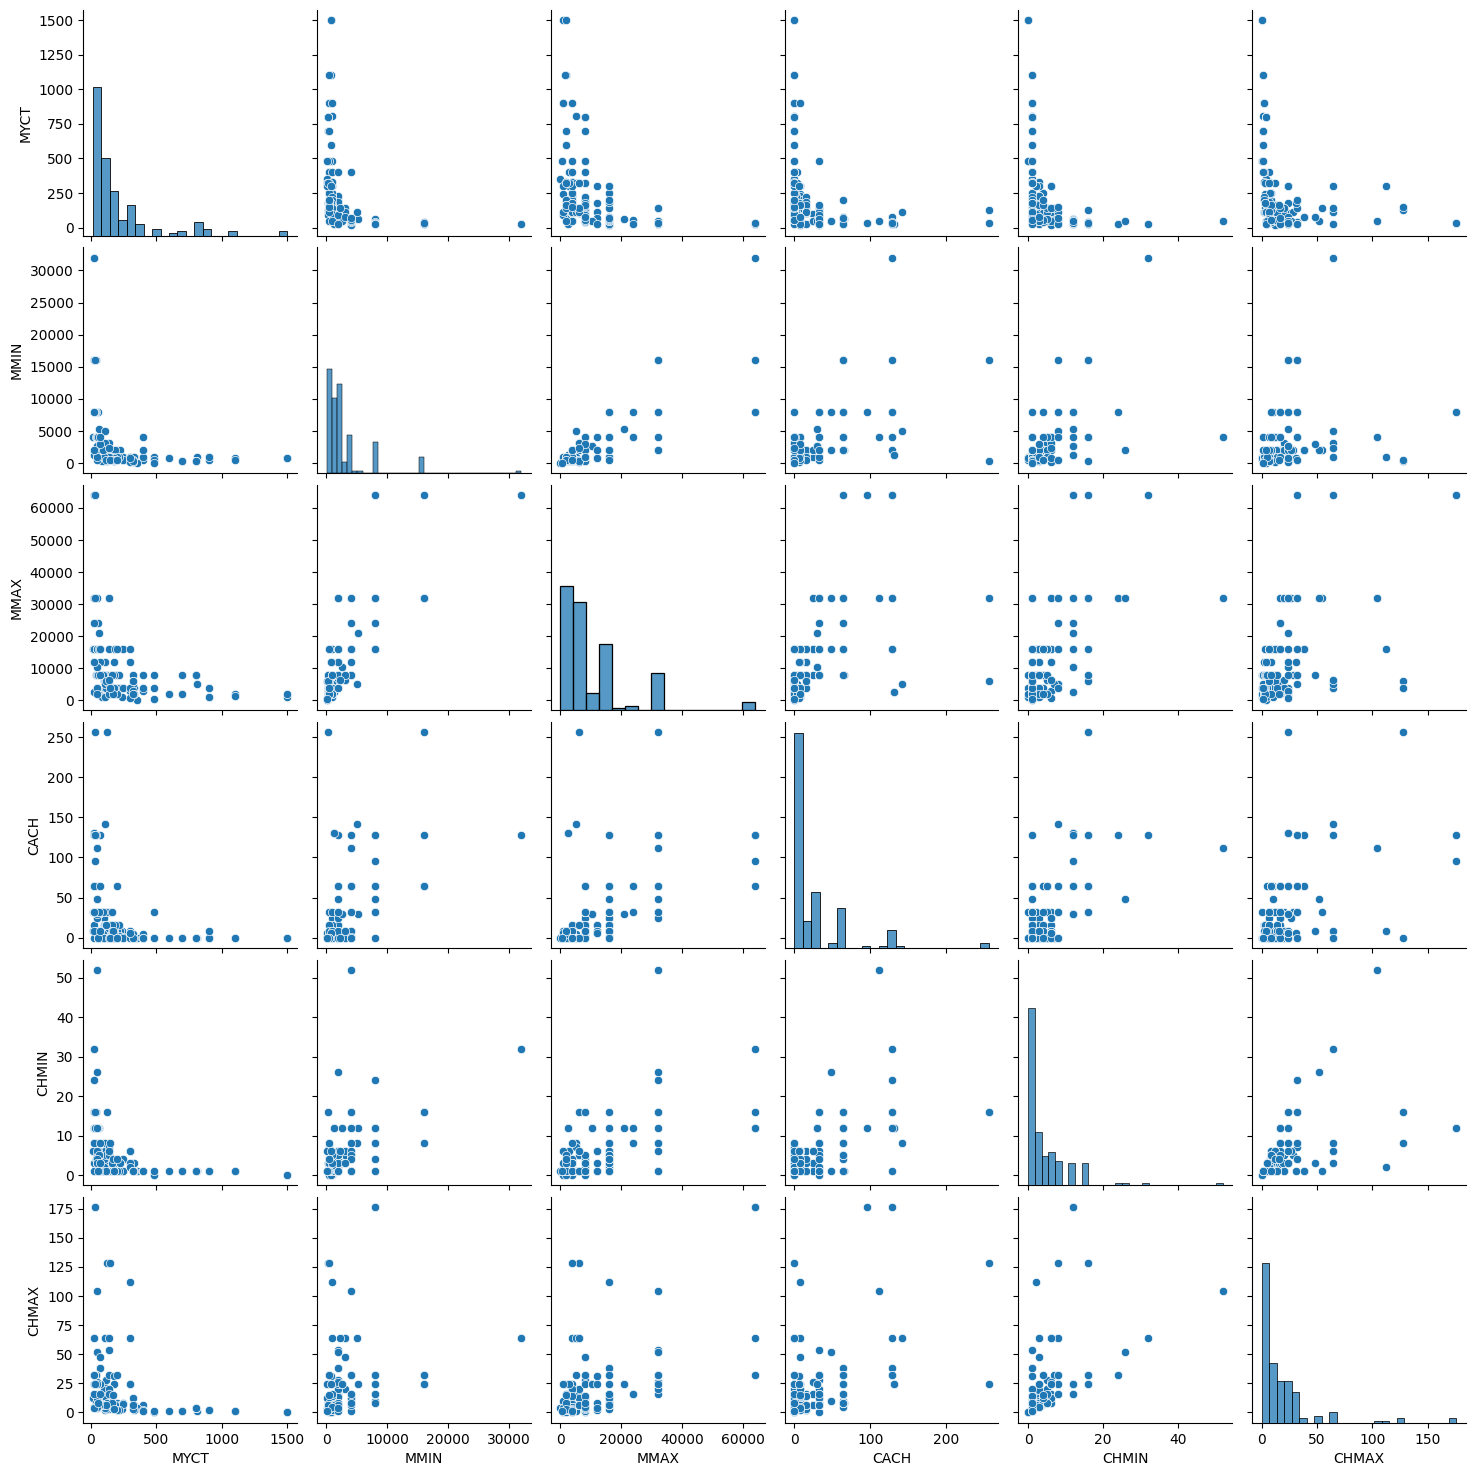

In [ ]:
sns.pairplot(X_train)

In [ ]:
# Перевірка підсумкової статистики

X_train.describe()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,207.958084,2900.826347,11761.161677,26.071856,4.760479,18.616766
std,266.772823,4165.950964,12108.332354,42.410014,6.487439,27.489919
min,17.000000,64.000000,64.000000,0.000000,0.000000,0.000000
25%,50.000000,768.000000,4000.000000,0.000000,1.000000,5.000000
50%,110.000000,2000.000000,8000.000000,8.000000,2.000000,8.000000
75%,232.500000,3100.000000,16000.000000,32.000000,6.000000,24.000000
max,1500.000000,32000.000000,64000.000000,256.000000,52.000000,176.000000


In [ ]:
# Перевірка відсутніх значень

X_train.isnull().sum()

,0
MYCT,0
MMIN,0
MMAX,0
CACH,0
CHMIN,0
CHMAX,0


У нас немає відсутніх значень

<a name='4'></a>

### 4 - Попередня обробка даних

Саме тут ми готуємо дані у належний формат для моделі машинного навчання.

Деревам рішень байдуже, масштабуються ознаки чи ні. Давайте налаштуємо конвеєр для масштабування ознак і використаємо його для перевірки цієї ідеї.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scale_pipe = Pipeline([
    ('scaler', StandardScaler())

])

X_train_scaled = scale_pipe.fit_transform(X_train)

<a name='5'></a>

### 5 - Навчальний регресор дерева рішень


In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()

tree_reg.fit(X_train, y_train)

DecisionTreeRegressor()

Давайте навчимо ту саму модель на масштабованих даних

In [ ]:
tree_reg_scaled = DecisionTreeRegressor()

tree_reg_scaled.fit(X_train_scaled, y_train)

DecisionTreeRegressor()

<a name='6'></a>

### 6 - Оцінка дерев рішень

Давайте спочатку перевіримо середню квадратичну помилку під час навчання. Не рекомендується оцінювати модель на основі тестових даних, оскільки ми її ще не вдосконалили. Ми зробимо функцію, щоб було легше і щоб уникнути повторів

In [ ]:
from sklearn.metrics import mean_squared_error

def predict(input_data,model,labels):
    """
    Взяти вхідні дані, модель і мітки та повернути передбачення

    """

    preds = model.predict(input_data)
    mse = mean_squared_error(labels,preds)
    rmse = np.sqrt(mse)
    rmse

    return rmse

In [ ]:
predict(X_train, tree_reg, y_train)

np.float64(9.724590719956222)

 коли навчальні дані масштабуються...

In [ ]:
predict(X_train_scaled, tree_reg_scaled, y_train)

np.float64(9.724590719956222)

Як бачите, різниці немає взагалі. Тож у ваших майбутніх проектах із використанням дерев рішень, незалежно від того, масштабуєте ви дані чи ні, на ваші прогнози це не вплине.

Але не робіть цього....

In [ ]:
predict(X_train_scaled, tree_reg, y_train)

np.float64(200.73068620226837)

Якщо ви бачите параметри, які ми передали у функції прогнозування вище, є масштабовані дані, модель, навчена на немасштабованих даних, і мітки (y_train). Як ви вже здогадалися, це повна невідповідність, яка призвела до поганих результатів. Якщо ви навчили модель на масштабованих даних, дані, на основі яких ви прогнозуєте модель, також повинні бути масштабовані таким же чином.

Спробуємо вдосконалити модель.

<a name='7'></a>

### 7 - Покращення дерев рішень

In [ ]:
tree_reg.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

Ми бачили, що один із способів покращити модель дерева рішень — це знайти правильну кількість max_depth і кілька інших параметрів. Давайте використаємо GridSearch, щоб знайти найкращі гіперпараметри. Зауважте, що це може закінчитися перенавчанням, оскільки у нас невеликий набір даних. Але оскільки ми робимо це з учбовою метою (ви можете адаптувати це до вашої проблеми), давайте це зробимо

In [ ]:
from sklearn.model_selection import GridSearchCV

params_grid = {'max_leaf_nodes': list(range(0, 10)), 'min_samples_split': [0,1,2, 3, 4],
              'max_depth':[None,0,1,2,3]}

#refit за замовчуванням має значення true. Найкращий оцінювач навчається на всьому наборі даних

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), params_grid, verbose=1, cv=3, refit=True)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 250 candidates, totalling 750 fits


GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [None, 0, 1, 2, 3],
                         'max_leaf_nodes': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
                         'min_samples_split': [0, 1, 2, 3, 4]},
             verbose=1)

In [ ]:
grid_search.best_params_

{'max_depth': None, 'max_leaf_nodes': 9, 'min_samples_split': 4}

In [ ]:
grid_search.best_estimator_

DecisionTreeRegressor(max_leaf_nodes=9, min_samples_split=4, random_state=42)

In [ ]:
tree_best = grid_search.best_estimator_

Давайте знову зробимо прогноз на даних навчання

In [ ]:
predict(X_train, tree_best, y_train)

np.float64(34.999530266023044)

Як ми вже сказали, ми маємо перенавчання. RMSE для нашого невеликого набору даних був досить гарним (і ви, ймовірно, не використовували б дерева рішень для невеликих даних, як це ми використовуємо).

Нарешті ми можемо оцінити модель на тестовому наборі. Скористаємося оригінальною моделлю.

In [ ]:
predict(X_test, tree_reg, y_test)

np.float64(42.273838020132274)

Очевидно, що модель переобладнана, а вдосконалення, які ми спробували, нічого не покращили. Це не проблема моделі чи нашого підходу до вдосконалення моделі. Дерева рішень — це складні моделі даних

Ми дізналися фундаментальну ідею, що лежить в основі дерев рішень, і використали її для прогнозування продуктивності ЦП. У наступній частині лабораторній роботі ми будемо використовувати дерева рішень для завдання класифікації, і ми будемо використовувати реальний набір даних, щоб ми могли практично вдосконалити модель дерева рішень

<a name='0'></a>
# Дерева рішень для класифікації



* 1 - Імпорт
* 2 - Завантаження даних
* 3 - Дослідницький аналіз
* 4 - Попередня обробка даних
* 5 - Навчання дерева рішень
* 6 - Оцінка дерев рішень
* 7 - Покращення дерев рішень

<a name='1'></a>
### 1 - Імпорт

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

<a name='2'></a>

### 2 - Завантаження даних

У цій класифікаційній задачі з деревами рішень ми будемо використовувати набір даних про вибір автомобіля, який доступний у [OpenML](https://www.openml.org/d/21) щоб передбачити прийнятність автомобіля з урахуванням інформації про автомобіль. Ми завантажимо його за допомогою функції Sklearn `fetch_openml`.

Версія даних, які ми отримуємо, — 2. У версії 1 набору даних цільовий клас мав 4 класи (unacc, acc, good, vgood), але в другій версії основний клас — Positive(P), тоді як решта негативні (P). Якщо ви хочете переглянути версію 1, ви можете змінити параметр версії в секції нижче.

Ось інформація про функції:

* *buying*: ціна покупки автомобіля(vhigh, high, med, low)
* maint: ціна технічного обслуговування автомобіля (vhigh, high, med, low)
* *doors*: кількість дверей (2,3,4,5more)
* *persons*: кількість осіб, які можуть перевозитися в автомобілі. Їх буває 2, 4, і more.
* *lug_boot*: розмір багажника (small, med, big)
* *safety*: розрахункова безпека автомобіля (low, med, high)
* *BinaryClass(target feature)*: клас прийнятності автомобіля. Або позитивний (P), або негативний (N).


In [ ]:
from sklearn.datasets import fetch_openml

car_data = fetch_openml(name='car', version=2)

In [ ]:
type(car_data)

sklearn.utils._bunch.Bunch

In [ ]:
car_data.details

{'id': '991',
 'name': 'car',
 'version': '2',
 'description_version': '1',
 'format': 'ARFF',
 'upload_date': '2014-10-04T22:44:31',
 'licence': 'Public',
 'url': 'https://openml.org/data/v1/download/53525/car.arff',
 'parquet_url': 'https://data.openml.org/datasets/0000/0991/dataset_991.pq',
 'file_id': '53525',
 'default_target_attribute': 'binaryClass',
 'tag': ['Automobiles',
  'Data Science',
  'derived',
  'mythbusting_1',
  'study_1',
  'study_15',
  'study_20',
  'study_41',
  'study_7'],
 'visibility': 'public',
 'status': 'active',
 'processing_date': '2020-11-20 20:17:54',
 'md5_checksum': '49c57b793eef1b8e55f297e5e019fdbf'}

In [ ]:
car_data.details['version']

'2'

In [ ]:
# Опис даних

print(car_data.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

Binarized version of the original data set (see version 1). The multi-class target feature is converted to a two-class nominal target feature by re-labeling the majority class as positive ('P') and all others as negative ('N'). Originally converted by Quan Sun.

Downloaded from openml.org.


In [ ]:
# Відображення назв ознак

car_data.feature_names

['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

In [ ]:
# Отримання всього кадру даних

car_data = car_data.frame
car_data.head()

,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,small,low,P
1,vhigh,vhigh,2,2,small,med,P
2,vhigh,vhigh,2,2,small,high,P
3,vhigh,vhigh,2,2,med,low,P
4,vhigh,vhigh,2,2,med,med,P


In [ ]:
type(car_data)

pandas.core.frame.DataFrame

<a name='3'></a>
### 3 - Дослідницький аналіз


Перш ніж проводити пошуковий аналіз, давайте отримаємо навчальні та тестові дані.

### Поділ даних на навчальні та тестові набори

In [ ]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(car_data, test_size=0.1,random_state=20)

print('Розмір навчальних даних: {} \n Розмір тестових даних: {}'.format(len(train_data), len(test_data)))

Розмір навчальних даних: 1555 
 Розмір тестових даних: 173


### Перевірка підсумкової статистики

In [ ]:
# еревірка підсумкової статистики

train_data.describe()

,buying,maint,doors,persons,lug_boot,safety,binaryClass
count,1555,1555,1555,1555,1555,1555,1555
unique,4,4,4,3,3,3,2
top,med,low,2,2,med,low,P
freq,402,392,393,521,522,528,1097


### Перевірка відсутніх значень

In [ ]:
# Перевірка відсутніх значень
train_data.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
binaryClass,0


У нас немає відсутніх значень

### Перевірка категорійних ознак

Давайте розглянемо деякі категоричні характеристики, які є в наборі даних, майже всі пов’язані з цим. Давайте побачимо це

In [ ]:
train_data['buying'].value_counts()

,count
buying,
med,402
vhigh,387
high,385
low,381


<Axes: xlabel='buying', ylabel='count'>

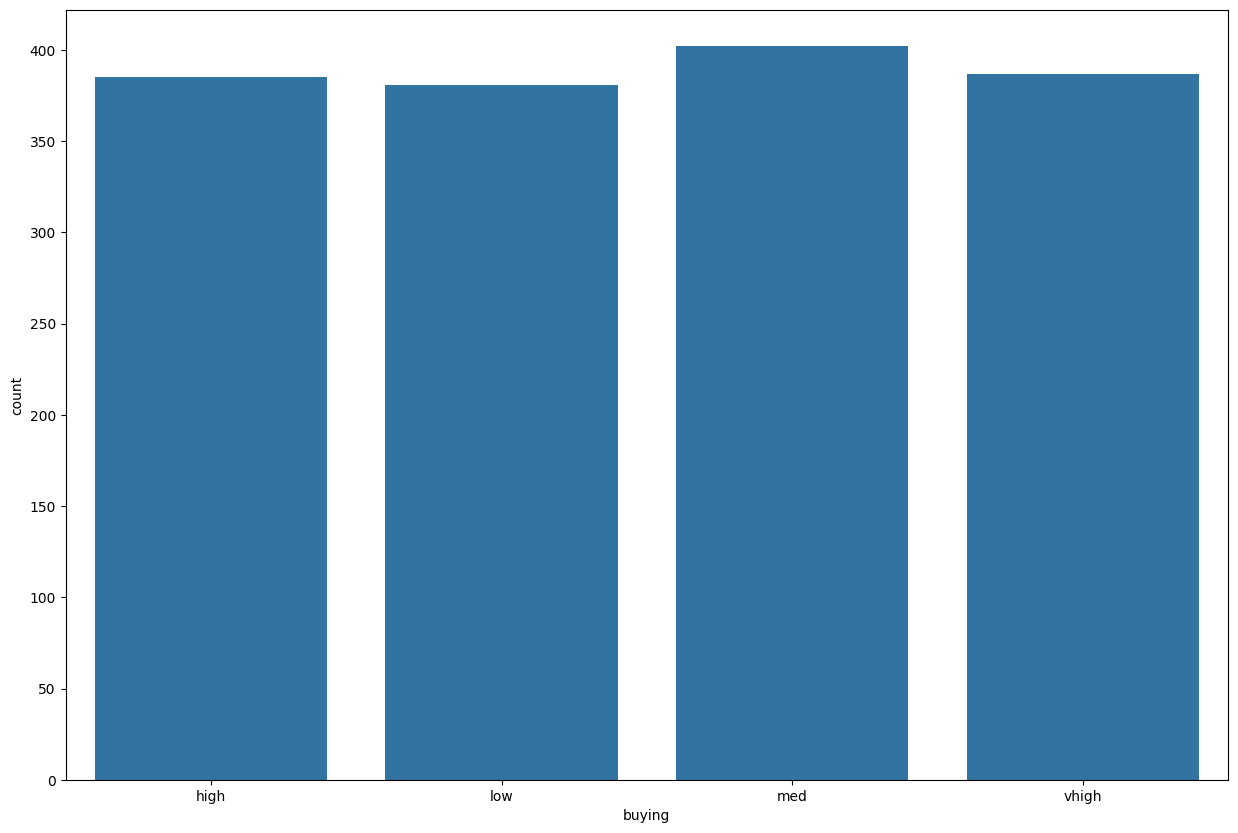

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='buying')

<Axes: xlabel='buying', ylabel='count'>

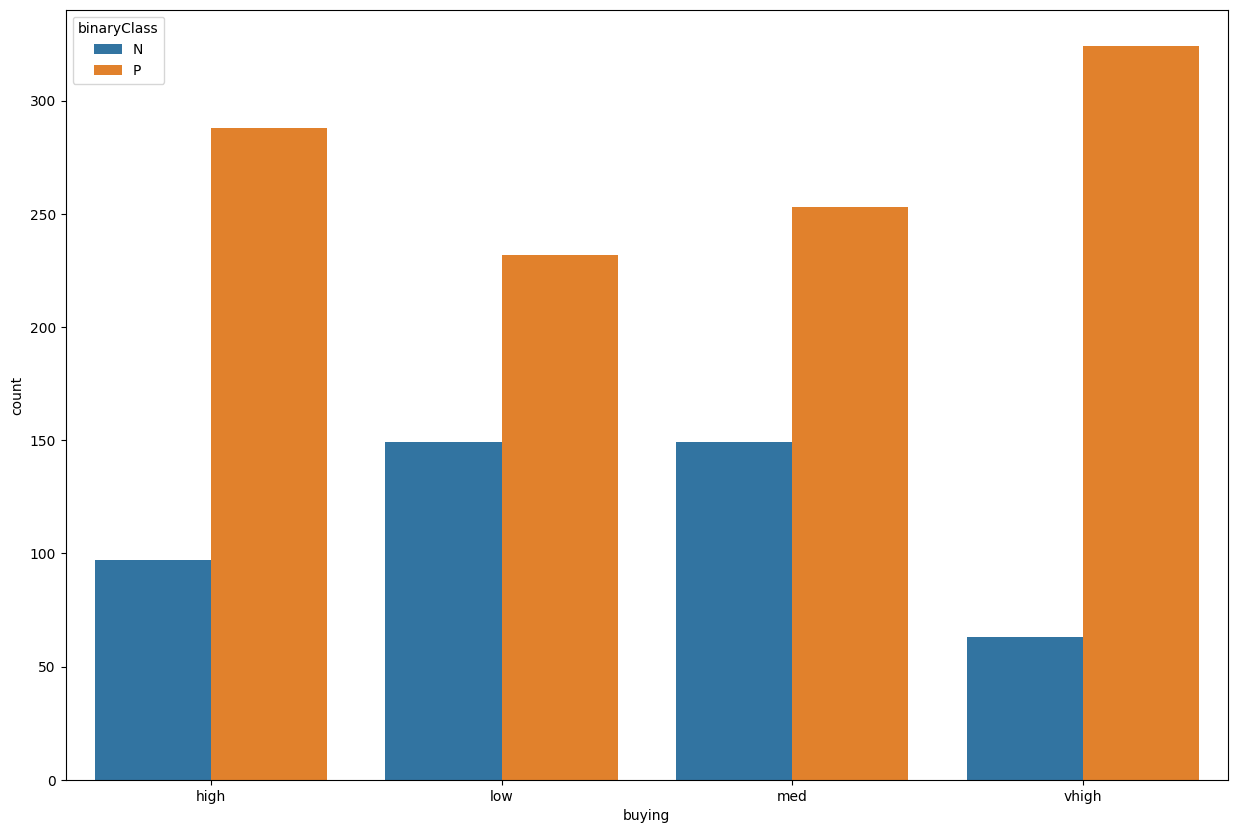

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='buying', hue='binaryClass')

Як ви можете бачити вище, основний клас у ціні покупки є медіанним (`med`).

In [ ]:
train_data['maint'].value_counts()

,count
maint,
low,392
med,390
high,387
vhigh,386


<Axes: xlabel='maint', ylabel='count'>

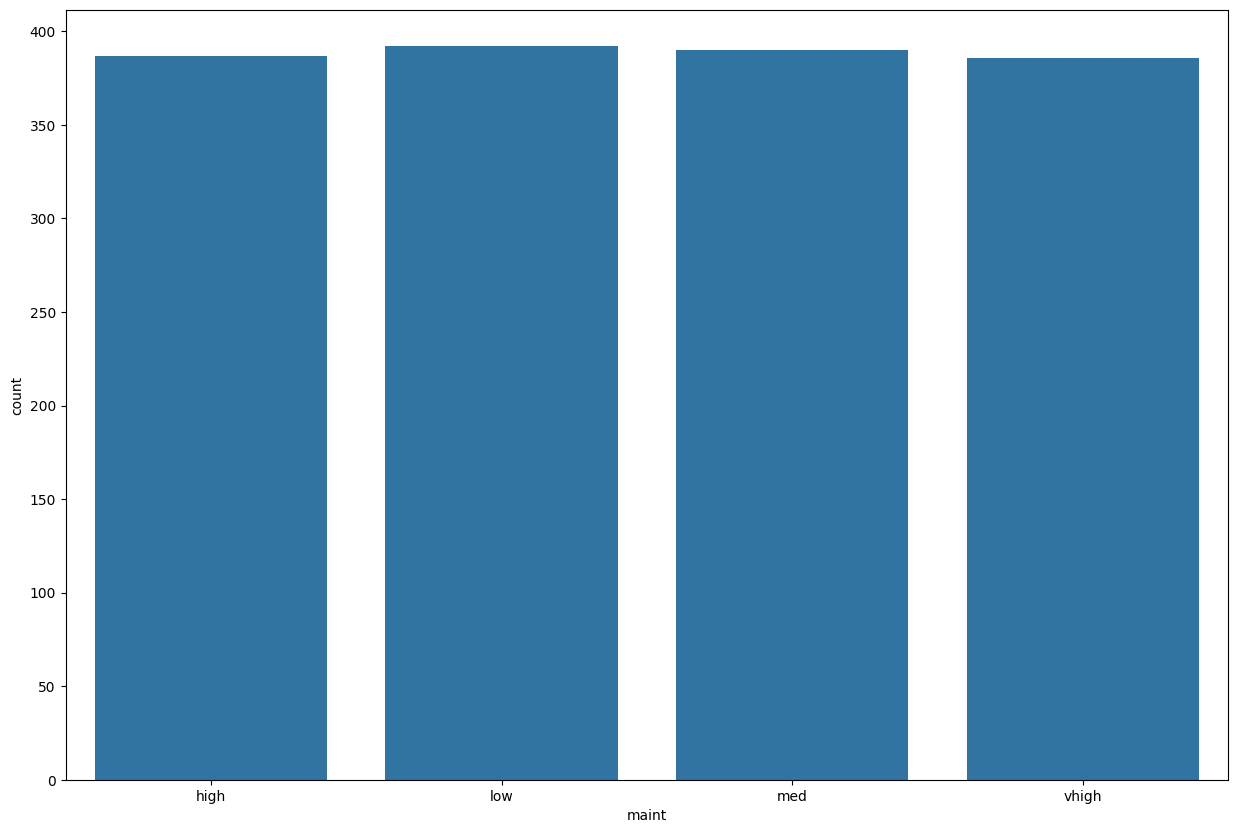

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='maint')

<Axes: xlabel='maint', ylabel='count'>

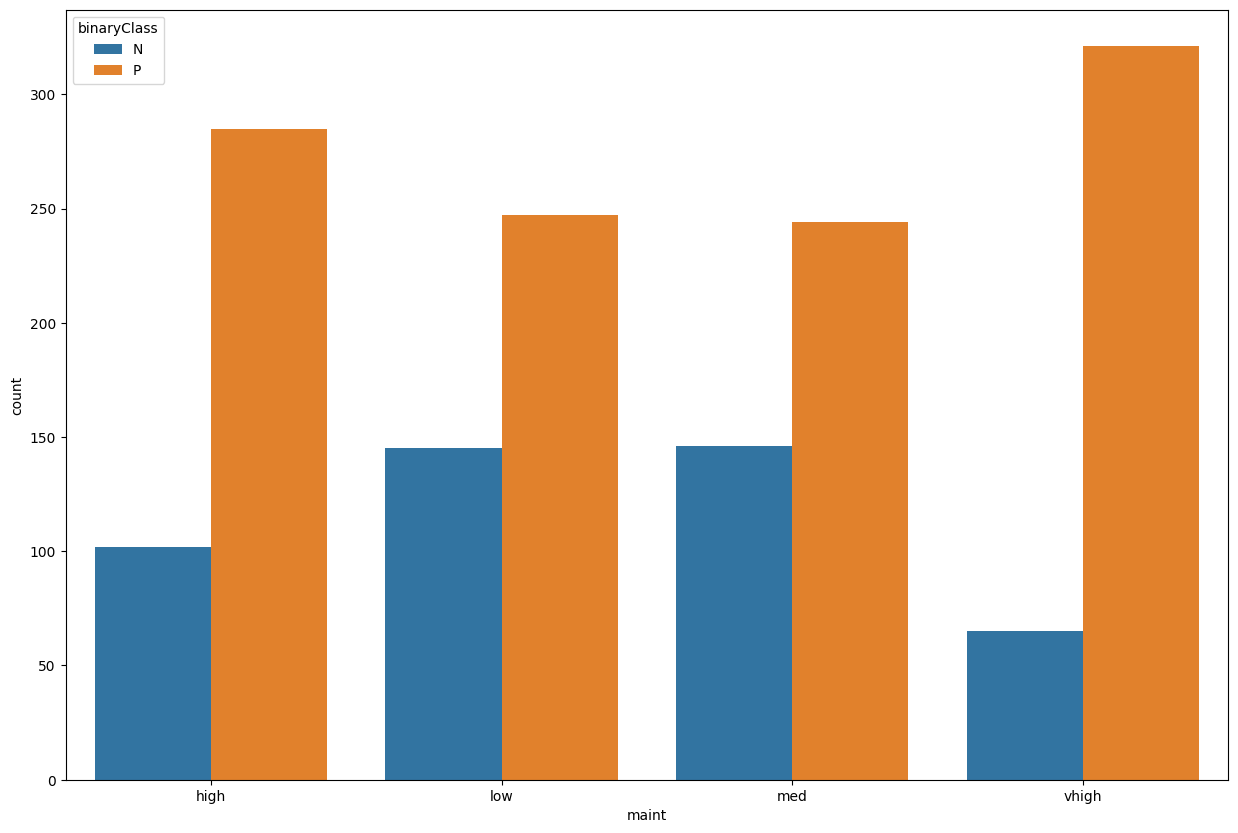

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='maint', hue='binaryClass')

Давайте також перевіримо, що в doors.

In [ ]:
train_data['doors'].value_counts()

,count
doors,
2,393
4,393
5more,389
3,380


<Axes: xlabel='doors', ylabel='count'>

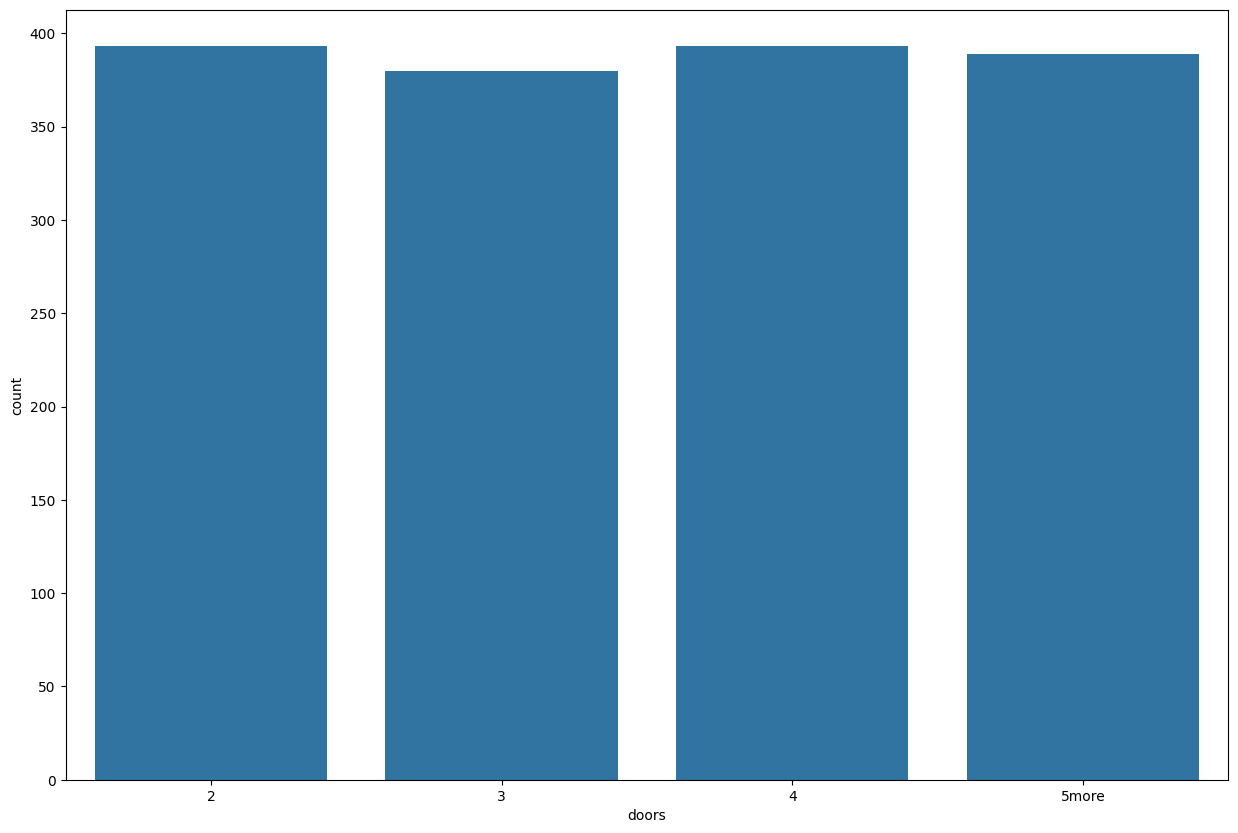

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='doors')

<Axes: xlabel='doors', ylabel='count'>

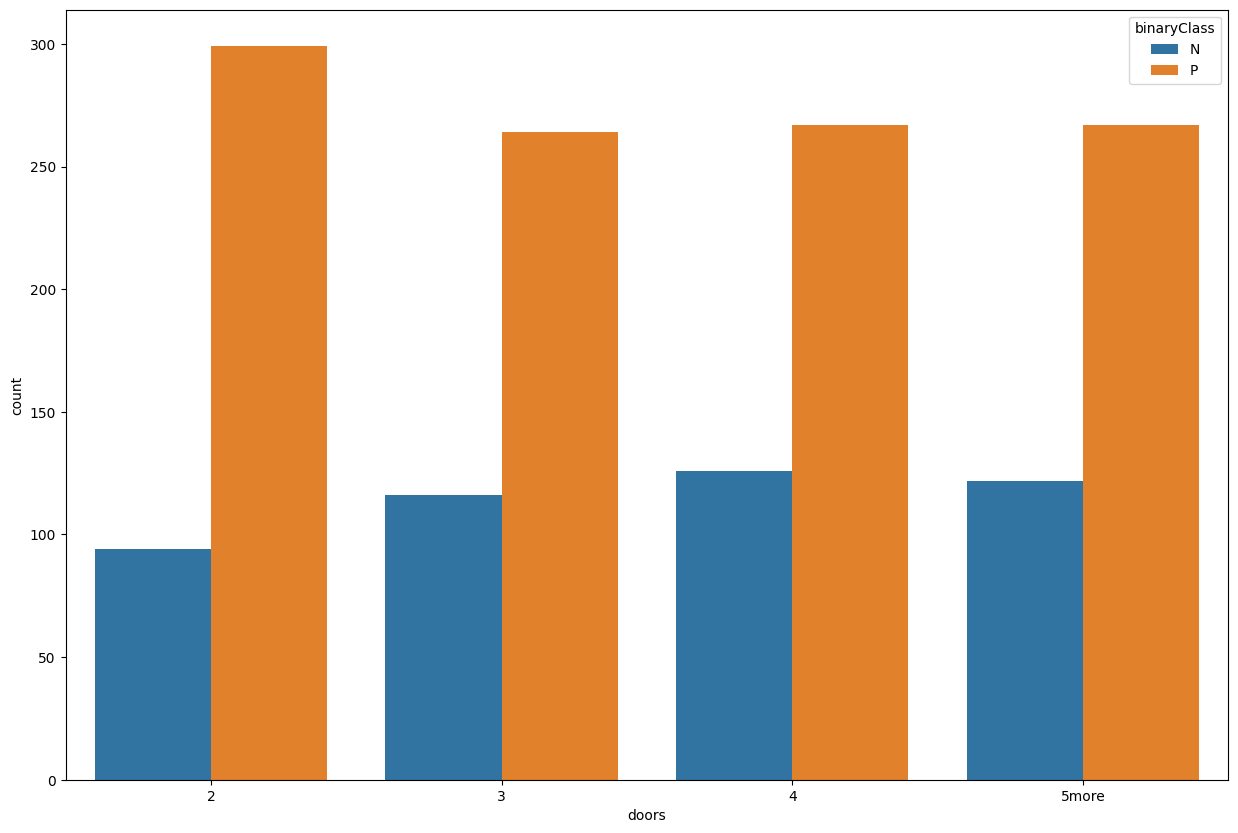

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='doors', hue='binaryClass')

Нічого приголомшливого у вартості обслуговування. Усі автомобілі мають однакові витрати на обслуговування

In [ ]:
train_data['persons'].value_counts()

,count
persons,
2,521
more,521
4,513


<Axes: xlabel='persons', ylabel='count'>

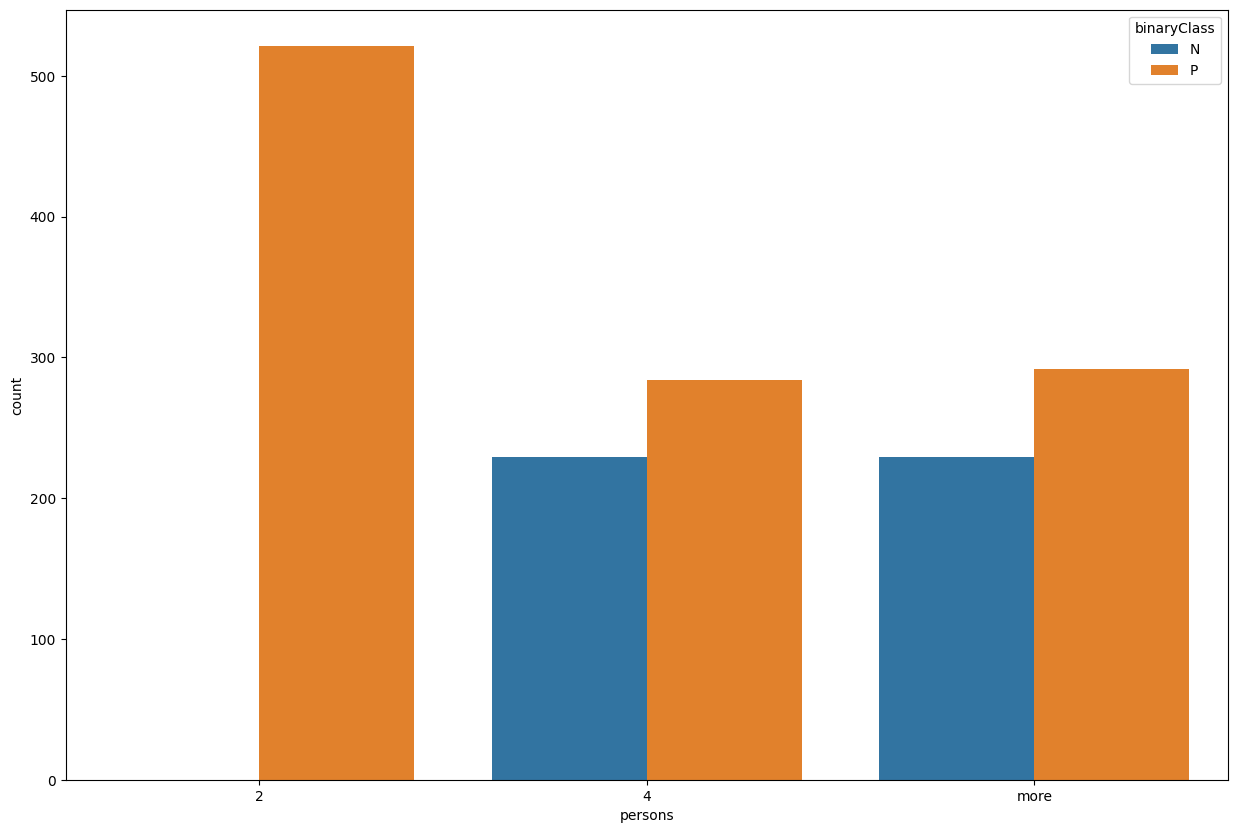

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='persons', hue='binaryClass')

In [ ]:
train_data['lug_boot'].value_counts()

,count
lug_boot,
med,522
small,517
big,516


<Axes: xlabel='lug_boot', ylabel='count'>

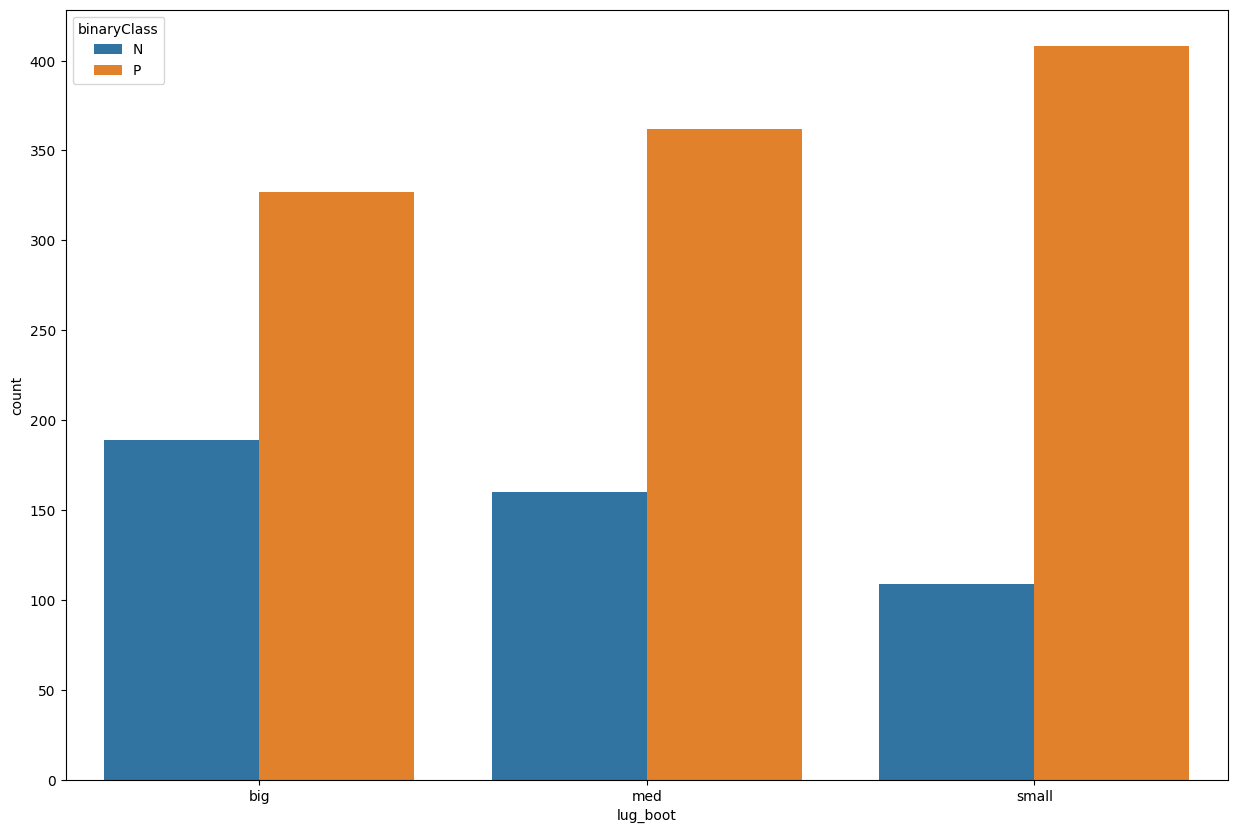

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='lug_boot', hue='binaryClass')

In [ ]:
train_data['safety'].value_counts()

,count
safety,
low,528
high,514
med,513


<Axes: xlabel='safety', ylabel='count'>

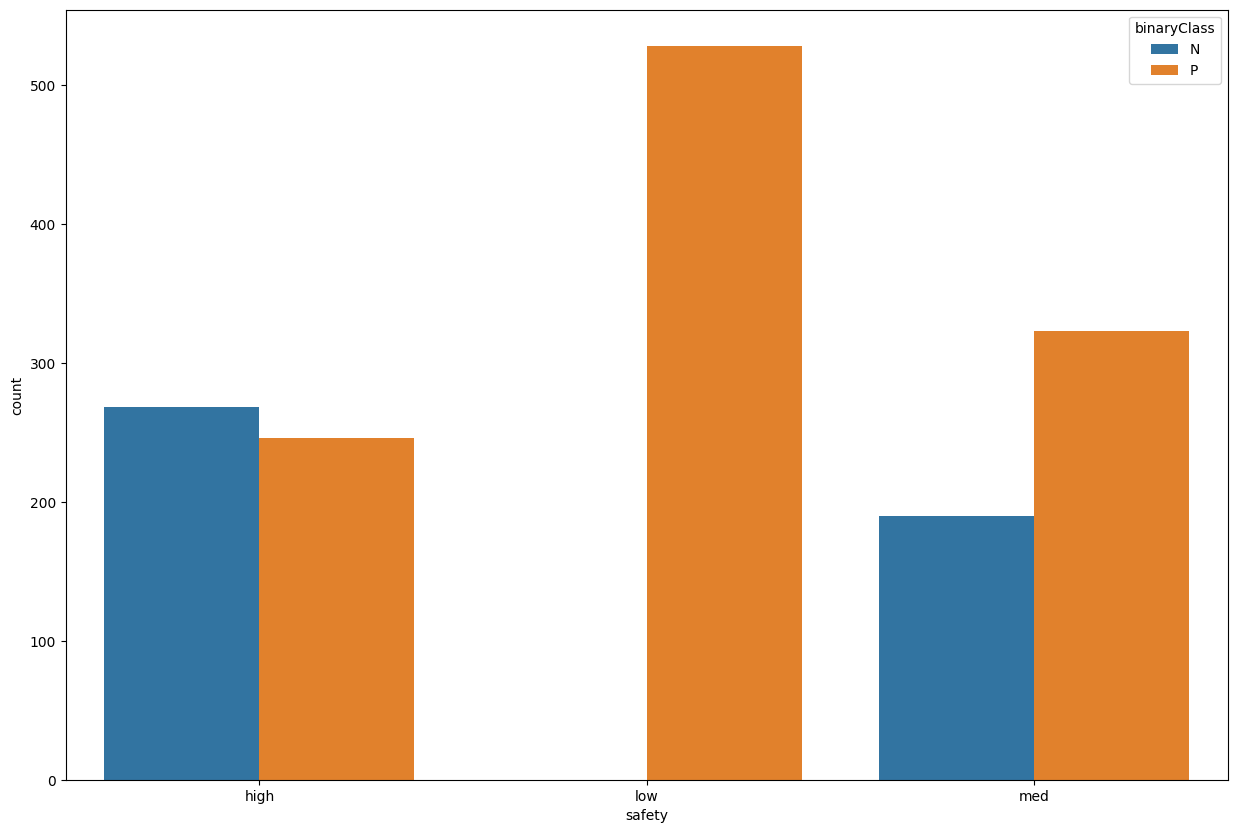

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='safety', hue='binaryClass')

In [ ]:
train_data['binaryClass'].value_counts()

,count
binaryClass,
P,1097
N,458


<Axes: xlabel='binaryClass', ylabel='count'>

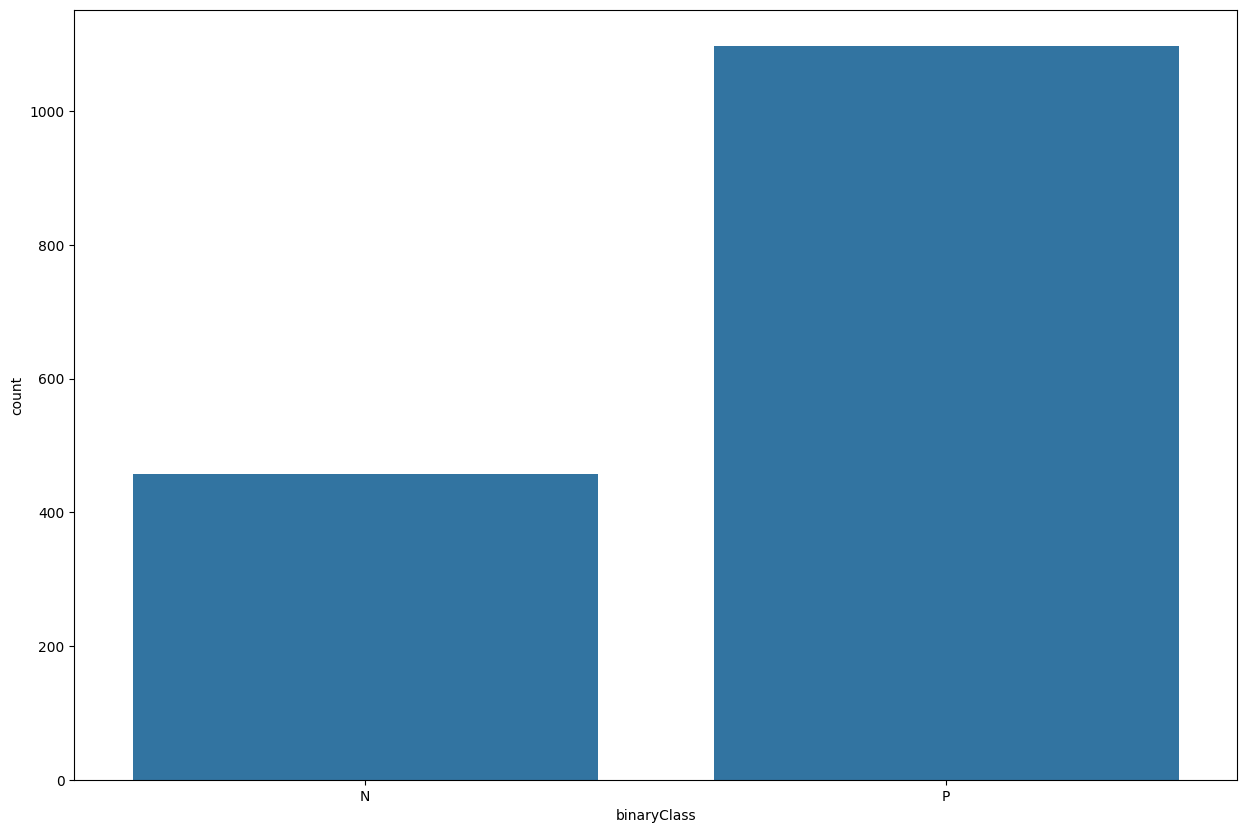

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='binaryClass')

Як бачите, наші дані повністю спотворені/незбалансовані. Позитивних прикладів у 2 рази більше, ніж негативних.

Тож під час оцінювання моделі ми пам’ятатимемо, що точність не є правильним показником у цьому випадку. Реальні набори даних постачаються зі своїми унікальними сумішами, набір даних може бути незбалансованим. Можуть бути відсутні значення. Ми просто повинні знайти ефективний спосіб вирішення цих проблем. Тому знову ж таки для оцінки ми не будемо покладатися на точність

<a name='4'></a>

### 4 - Попередня обробка даних

Саме тут ми готуємо дані у належний формат для моделі машинного навчання.

### Обробка категоріальних ознак

Деревам рішень байдуже, масштабовані функції чи ні, і вони можуть працювати з категоріальними функціями. У документації є [примитка](https://scikit-learn.org/stable/modules/tree.html#tree) про те, що реалізація дерева sklearn не підтримує категорійні функції, однак ми все одне продовжимо роботу

Перш ніж працювати з категоріальними ознаками, давайте створимо навчальні вхідні дані та мітки

In [ ]:
car_train = train_data.drop('binaryClass', axis=1)
car_labels = train_data[['binaryClass']]

Давайте створимо конвеєр для кодування всіх функцій у вхідних даних навчання

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('ord_enc', OrdinalEncoder())

])

car_train_prepared = pipe.fit_transform(car_train)

Давайте також обробимо мітки. Мітки містять P і N, тому ми хочемо перетворити їх на числа. Тут замість використання звичайного кодувальника ми будемо використовувати кодувальник міток. Sklearn — це те, що він використовується для кодування цільових функцій

In [ ]:
from sklearn.preprocessing import LabelEncoder


label_enc = LabelEncoder()

car_labels_prepared = label_enc.fit_transform(car_labels)

<a name='5'></a>

### 5 - Навчальний класифікатор дерева рішень


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier()

tree_clf.fit(car_train_prepared, car_labels_prepared)

DecisionTreeClassifier()

Давайте навчимо ту саму модель на масштабованих даних

In [ ]:
# якщо ви запустите це, це буде помилка.
# Реалізація дерева SKlearn не підтримує категоріальні функції

#from sklearn.tree import DecisionTreeClassifier

#tree_clf = DecisionTreeClassifier()

#tree_clf.fit(car_train, car_labels)

<a name='6'></a>

### 6 - Оцінка дерев рішень

Давайте створимо 3 функції для відображення точності, матриці помилок і звіту про класифікацію. Звіт про класифікацію містить усі корисні показники, такі як точність, запам’ятовування та оцінка f1.

In [ ]:
from sklearn.metrics import accuracy_score

def accuracy(input_data,model,labels):
    """
    Взяти вхідні дані, модель і мітки та повернути точність

    """

    preds = model.predict(input_data)
    acc = accuracy_score(labels,preds)

    return acc

In [ ]:
from sklearn.metrics import confusion_matrix

def conf_matrix(input_data,model,labels):
    """
    Візьміть вхідні дані, модель і мітки та поверніть матрицю помилок

    """

    preds = model.predict(input_data)
    cm = confusion_matrix(labels,preds)

    return cm

In [ ]:
from sklearn.metrics import classification_report

def class_report(input_data,model,labels):
    """
    Взяти вхідні дані, модель і мітки та повернути звіт про класифікацію

    """

    preds = model.predict(input_data)
    report = classification_report(labels,preds)
    report = print(report)

    return report

Знайдемо точність на навчальному наборі

In [ ]:
accuracy(car_train_prepared, tree_clf, car_labels_prepared)

1.0

Бачите. Дерева рішень переначились на набірі даних. Крім того, якщо ми добре пам’ятаємо, наші дані не збалансовані. У нас багато позитивних прикладів, ніж негативних

In [ ]:
conf_matrix(car_train_prepared, tree_clf, car_labels_prepared)

array([[ 458,    0],
       [   0, 1097]])

In [ ]:
class_report(car_train_prepared, tree_clf, car_labels_prepared)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       458
           1       1.00      1.00      1.00      1097

    accuracy                           1.00      1555
   macro avg       1.00      1.00      1.00      1555
weighted avg       1.00      1.00      1.00      1555



Модель явно перенавчилась. Давайте подивимося, як ми можемо це врегулювати

<a name='7'></a>

### 7 - Покращення дерев рішень

In [ ]:
tree_clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

Один із способів уникнути перенавчання — зменшити максимальну глибину дерева, встановлену гіперпараметром `max_depth`. Подібним чином ми можемо спробувати зменшити всі гіперпараметри за допомогою `max` одночасно збільшуючи параметри `min_`.

Крім того, ми встановили `class_weight` у `balanced` оскільки наш набір даних незбалансований. Встановивши значення `balanced`, модель автоматично регулюватиме вагу класу на основі кількості доступних зразків у всіх класах.


Давайте скористаємося GridSearch, щоб знайти найкращі значення цих гіперпараметрів.

In [ ]:
# Приховаємо warnings які повертає grid search

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import GridSearchCV

params_grid = {'max_leaf_nodes': list(range(0, 10)),
               'min_samples_split': [0,1,2, 3, 4],
               'min_samples_leaf': [0,1,2, 3, 4],
               'max_depth':[0,1,2,3,4,5],
               'max_features':[0,1,2,3,4,5],
              'max_leaf_nodes':[0,1,2,3,4,5]}

#refit за замовчуванням має значення true. Найкращий оцінювач навчається на всьому наборі даних

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'), params_grid, verbose=1, cv=3, refit=True)

grid_search.fit(car_train_prepared, car_labels_prepared)

Fitting 3 folds for each of 5400 candidates, totalling 16200 fits


GridSearchCV(cv=3,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [0, 1, 2, 3, 4, 5],
                         'max_features': [0, 1, 2, 3, 4, 5],
                         'max_leaf_nodes': [0, 1, 2, 3, 4, 5],
                         'min_samples_leaf': [0, 1, 2, 3, 4],
                         'min_samples_split': [0, 1, 2, 3, 4]},
             verbose=1)

In [ ]:
grid_search.best_params_

{'max_depth': 4,
 'max_features': 5,
 'max_leaf_nodes': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(class_weight='balanced', max_depth=4, max_features=5,
                       max_leaf_nodes=5, random_state=42)

In [ ]:
tree_best = grid_search.best_estimator_

Також можемо побудувати дерево вдосконаленої моделі.

In [ ]:
car_data.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety',
       'binaryClass'],
      dtype='object')

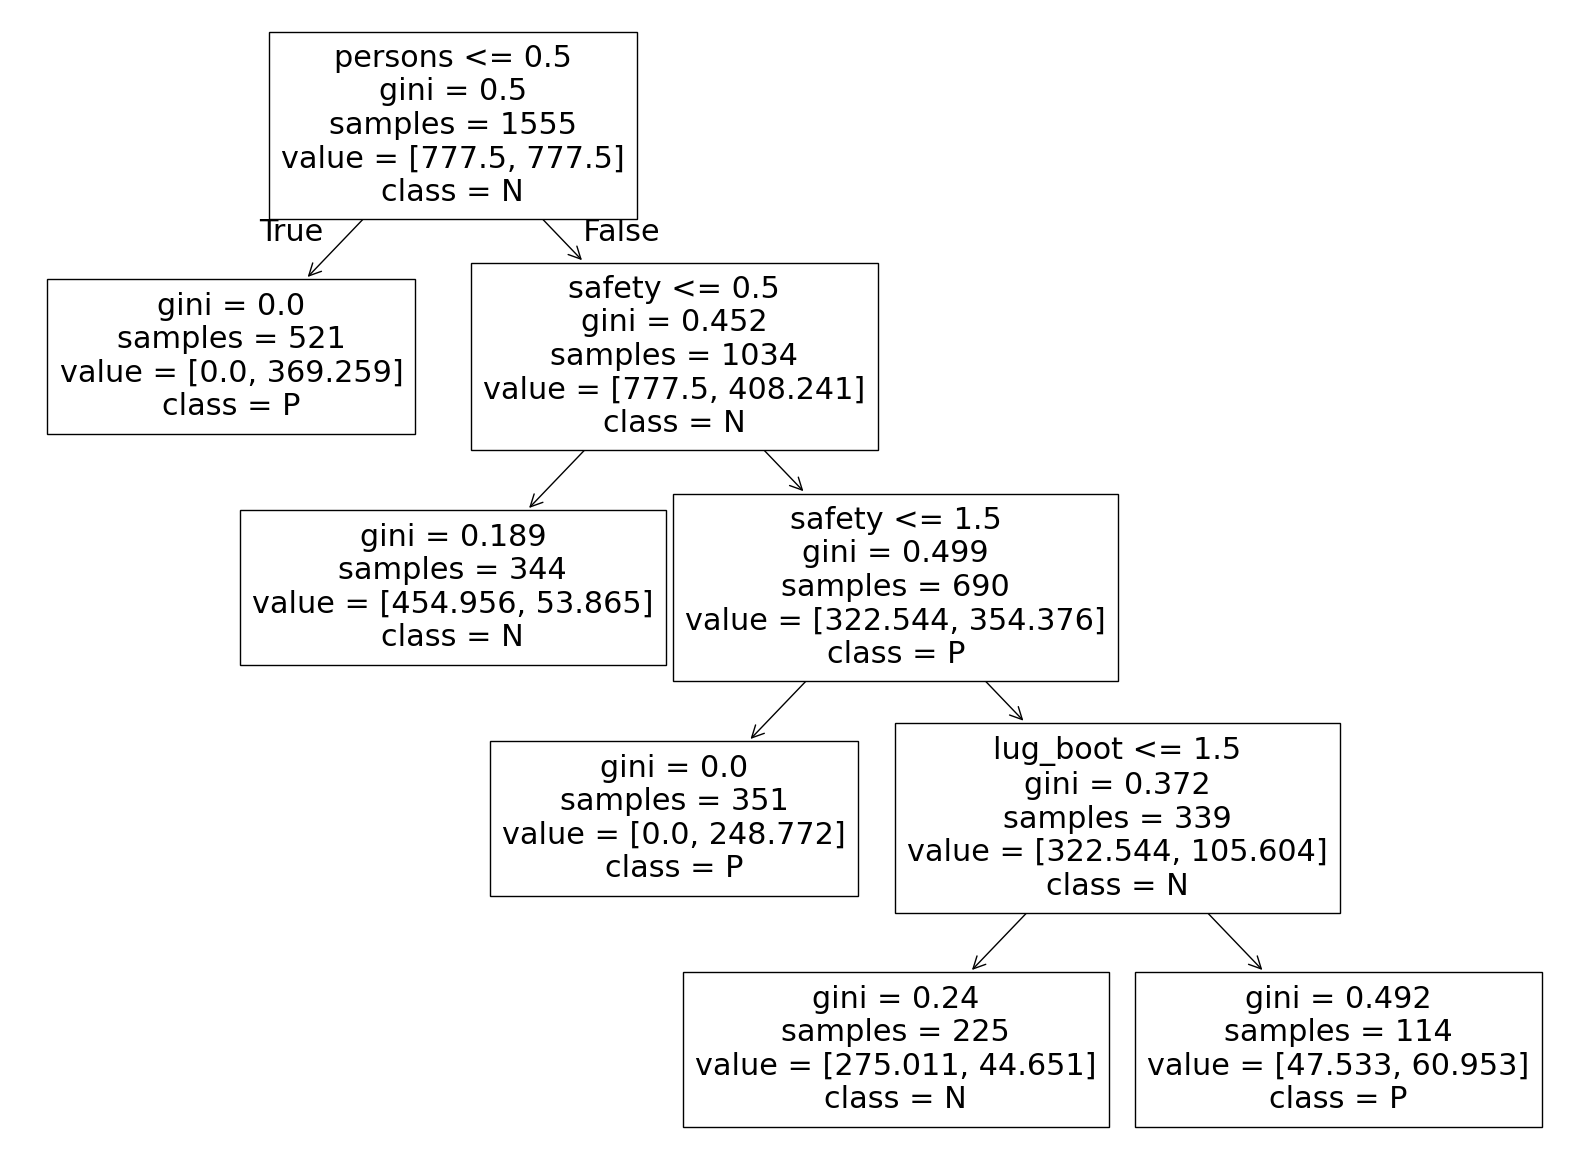

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,15))
plot_tree(tree_best, feature_names=car_train.columns, class_names=['N','P']);

Давайте знову зробимо прогноз на даних навчання

In [ ]:
accuracy(car_train_prepared, tree_best, car_labels_prepared)

0.8926045016077171

In [ ]:
conf_matrix(car_train_prepared, tree_best, car_labels_prepared)

array([[430,  28],
       [139, 958]])

У матриці помилок кожен рядок представляє фактичний клас, а кожен стовпець представляє прогнозований клас.

Отже, з результатів вище:

* 430 негативних прикладів (N) були правильно передбачені як негативні (`true negatives`).
* 28 негативних прикладів (N) були неправильно класифіковані як позитивні приклади, хоча вони насправді є негативними (`false positives`).
* 139 позитивних прикладів були неправильно класифіковані як негативні (N), хоча насправді вони є позитивними (P)  (`false negatives`).
* 958 були правильно класифіковані як позитивні приклади (`true positives`).

In [ ]:
class_report(car_train_prepared, tree_best, car_labels_prepared)

              precision    recall  f1-score   support

           0       0.76      0.94      0.84       458
           1       0.97      0.87      0.92      1097

    accuracy                           0.89      1555
   macro avg       0.86      0.91      0.88      1555
weighted avg       0.91      0.89      0.90      1555



Це же набагато краще. Лише встановивши вагу класу `balanced` та знайшовши найкращі значення гіперпараметрів, ми змогли покращити нашу модель.

Якщо ви пам’ятаєте, негативний клас має менше прикладів, ніж позитивні класи. Ви можете побачити їх у `support` звіті про класифікацію. Але наша модель здатна правильно визначити їх на 76%, а також здатна ідентифікувати позитивні приклади на 97% без переобладнання. Це точність.

Кілька приміток щодо оцінки Precison/Recall/F1:

* Precision - це точність моделі щодо правильного прогнозування позитивних прикладів.
* Recall - це відношення позитивних прикладів, які правильно визначені моделлю.

* F1 - це середнє гармонійне значення точності та запам’ятовування.

Чим вище точність і запам'ятовування, тим вище оцінка F1. Але між ними є компроміс. Підвищення точності зменшить запам’ятовування, і навпаки. Тому буде справедливо сказати, що це залежить від проблеми, яку ви намагаєтеся вирішити, і показників, які ви хочете оптимізувати.


### Оцінка моделі на тестовому наборі

Лише після того, як ми вдосконалили модель, ми можемо передати її в тестовий набір. Якщо ми спробуємо показати тестовий набір моделі під час навчання, ми можемо спричинити потенційний витік, створюючи оманливі прогнози.

Крім того, ми застосуємо ті самі функції обробки, що й до навчального набору

In [ ]:
car_test = test_data.drop('binaryClass', axis=1)
car_test_labels = test_data['binaryClass']

In [ ]:
# Обробка категорійних функцій за допомогою конвеєра, який ми визначили раніше
# Ми не відповідаємо тестовим даним. Тільки трансформувати

car_test_prepared = pipe.transform(car_test)

In [ ]:
# Також обробляемо мітки

car_test_labels_prepared = label_enc.transform(car_test_labels)

Тепер ми можемо робити прогнози щодо тестового набору. Нам потрібно буде лише викликати функції метрик, які ми створили раніше

In [ ]:
accuracy(car_test_prepared, tree_best, car_test_labels_prepared)

0.8554913294797688

In [ ]:
conf_matrix(car_test_prepared, tree_best, car_test_labels_prepared)

array([[53,  7],
       [18, 95]])

In [ ]:
class_report(car_test_prepared, tree_best, car_test_labels_prepared)

              precision    recall  f1-score   support

           0       0.75      0.88      0.81        60
           1       0.93      0.84      0.88       113

    accuracy                           0.86       173
   macro avg       0.84      0.86      0.85       173
weighted avg       0.87      0.86      0.86       173



Модель ніколи не бачила тестового набору, але, як бачите, результати справді чудові. Модель може добре узагальнюватися на тестовому наборі, і це тому, що ми покращили її належним чином.

Таким чином, ми навчилися будувати та  удосконалювати (або справлятися з перенавчанням) класифікатор дерев рішень

<a name='0'></a>
# Випадкові ліси - вступ і регресія

Випадкові ліси — це потужні алгоритми машинного навчання, які використовуються для контрольованої класифікації та регресії. Випадкові ліси працюють шляхом усереднення прогнозів кількох рандомізованих дерев рішень. Дерева рішень мають тенденцію до переначання, тому, комбінуючи кілька дерев рішень, ефект переначання можна мінімізувати.

Випадкові ліси – це тип ансамблевих моделей.

На відміну від інших алгоритмів навчання, випадкові ліси забезпечують спосіб визначення важливості кожної функції, і це реалізовано в Sklearn.

## Випадкові ліси для регресії

* 1 - Імпорт
* 2 - Завантаження даних
* 3 - Дослідницький аналіз
* 4 - Попередня обробка даних
* 5 - Навчання регресору випадкових лісів
* 6 - Оцінка регресора випадкових лісів
* 7 - Покращення регресора випадкових лісів
* 8 – Важливість ознак
* 9 – Оцінка вдосконаленої моделі на тестовому наборі


<a name='1'></a>
### 1 - Імпорт

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

<a name='2'></a>

### 2 - Завантаження даних

У цьому завданні регресії з випадковими лісами ми будемо використовувати набір даних центрального процесора, доступний в  [OpenML](https://www.openml.org/t/5492). Ми завантажимо його за допомогою функції Sklearn - `fetch_openml`.

Ми передбачимо відносну продуктивність ЦП за такими даними:

* MYCT: час машинного циклу в наносекундах (integer)
* MMIN: мінімальна основна пам'ять у кілобайтах (integer)
* MMAX: максимальна основна пам'ять у кілобайтах (integer)
* CACH: кеш-пам'ять у кілобайтах (integer)
* CHMIN: мінімальна кількість каналів в одиницях (integer)
* CHMAX: максимальна кількість каналів в одиницях (integer)
* PRP: відносна ефективність(integer) (цільова змінна)

In [ ]:
# Давайте приховаємо попередження

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.datasets import fetch_openml

machine_cpu = fetch_openml(name='machine_cpu', version=1)

In [ ]:
type(machine_cpu)

sklearn.utils._bunch.Bunch

In [ ]:
machine_cpu.details

{'id': '230',
 'name': 'machine_cpu',
 'version': '1',
 'description_version': '1',
 'format': 'ARFF',
 'contributor': 'L. Torgo',
 'upload_date': '2014-04-23T13:20:36',
 'language': 'English',
 'licence': 'Public',
 'url': 'https://openml.org/data/v1/download/3667/machine_cpu.arff',
 'parquet_url': 'https://data.openml.org/datasets/0000/0230/dataset_230.pq',
 'file_id': '3667',
 'default_target_attribute': 'class',
 'version_label': '1',
 'citation': 'https://archive.ics.uci.edu/ml/citation_policy.html',
 'tag': ['Computing', 'Data Analysis', 'OpenML-Reg19'],
 'visibility': 'public',
 'original_data_url': 'http://www.ics.uci.edu/~mlearn/MLSummary.html',
 'status': 'active',
 'processing_date': '2020-11-20 19:15:43',
 'md5_checksum': 'e26d62e83069b74dff6cf492e06868a0'}

In [ ]:
machine_cpu.data.shape

(209, 6)

In [ ]:
print(machine_cpu.DESCR)

**Author**:   
**Source**: Unknown -   
**Please cite**:   

The problem concerns Relative CPU Performance Data. More information can be obtained in the UCI Machine
 Learning repository (http://www.ics.uci.edu/~mlearn/MLSummary.html).
 The used attributes are :
 MYCT: machine cycle time in nanoseconds (integer)
 MMIN: minimum main memory in kilobytes (integer)
 MMAX: maximum main memory in kilobytes (integer)
 CACH: cache memory in kilobytes (integer)
 CHMIN: minimum channels in units (integer)
 CHMAX: maximum channels in units (integer)
 PRP: published relative performance (integer) (target variable)
 
 Original source: UCI machine learning repository. 
 Source: collection of regression datasets by Luis Torgo (ltorgo@ncc.up.pt) at
 http://www.ncc.up.pt/~ltorgo/Regression/DataSets.html
 Characteristics: 209 cases; 6 continuous variables

Downloaded from openml.org.


In [ ]:
# Відображення імен ознак

machine_cpu.feature_names

['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX']

In [ ]:
# Отримання всього кадру даних

machine_data = machine_cpu.frame

In [ ]:
type(machine_data)

pandas.core.frame.DataFrame

<a name='3'></a>
### 3 - Дослідницький аналіз


Перш ніж проводити аналіз, давайте отримаємо навчальні та тестові дані

In [ ]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(machine_data, test_size=0.2,random_state=20)

print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(train_data), len(test_data)))

The size of training data is: 167 
The size of testing data is: 42


Давайте візуалізуємо гістограми всіх числових ознак

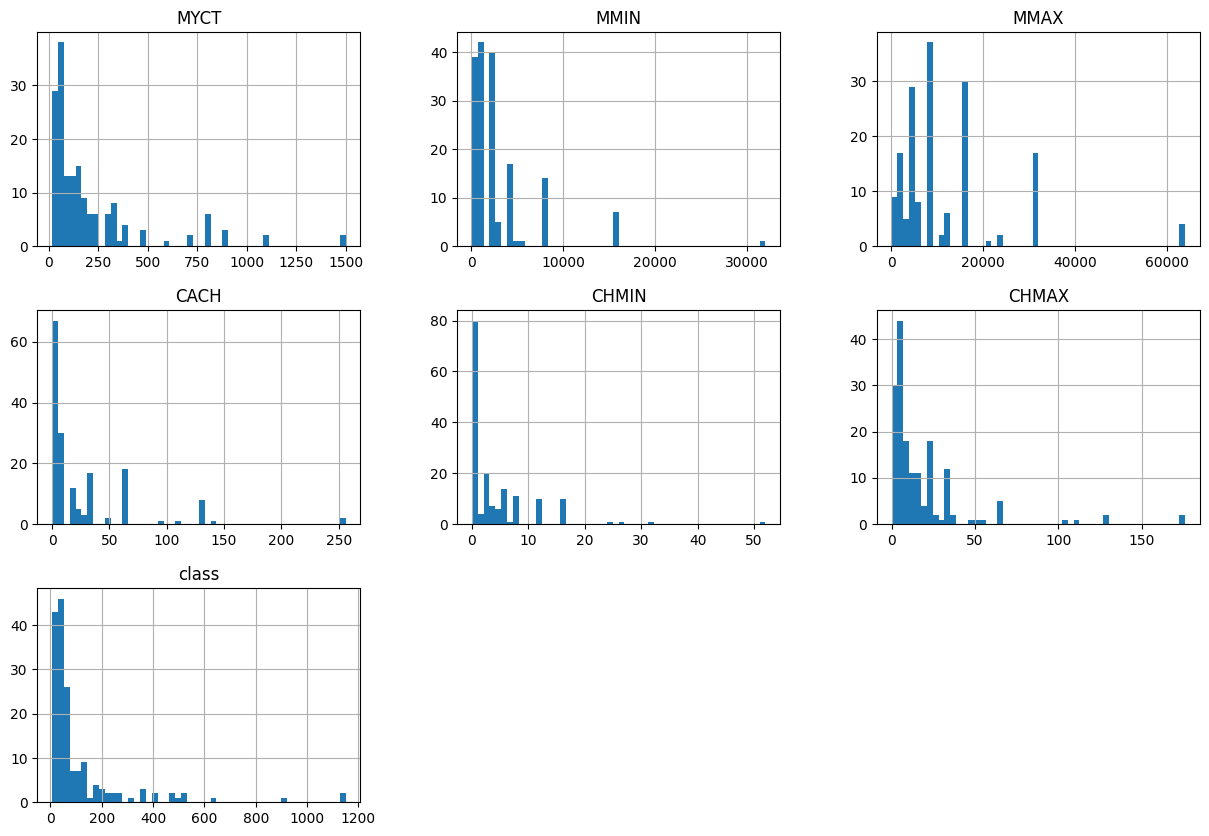

In [ ]:
train_data.hist(bins=50, figsize=(15,10))
plt.show()

Або ми можемо використовувати `sns.pairplot()` для перегляду даних.

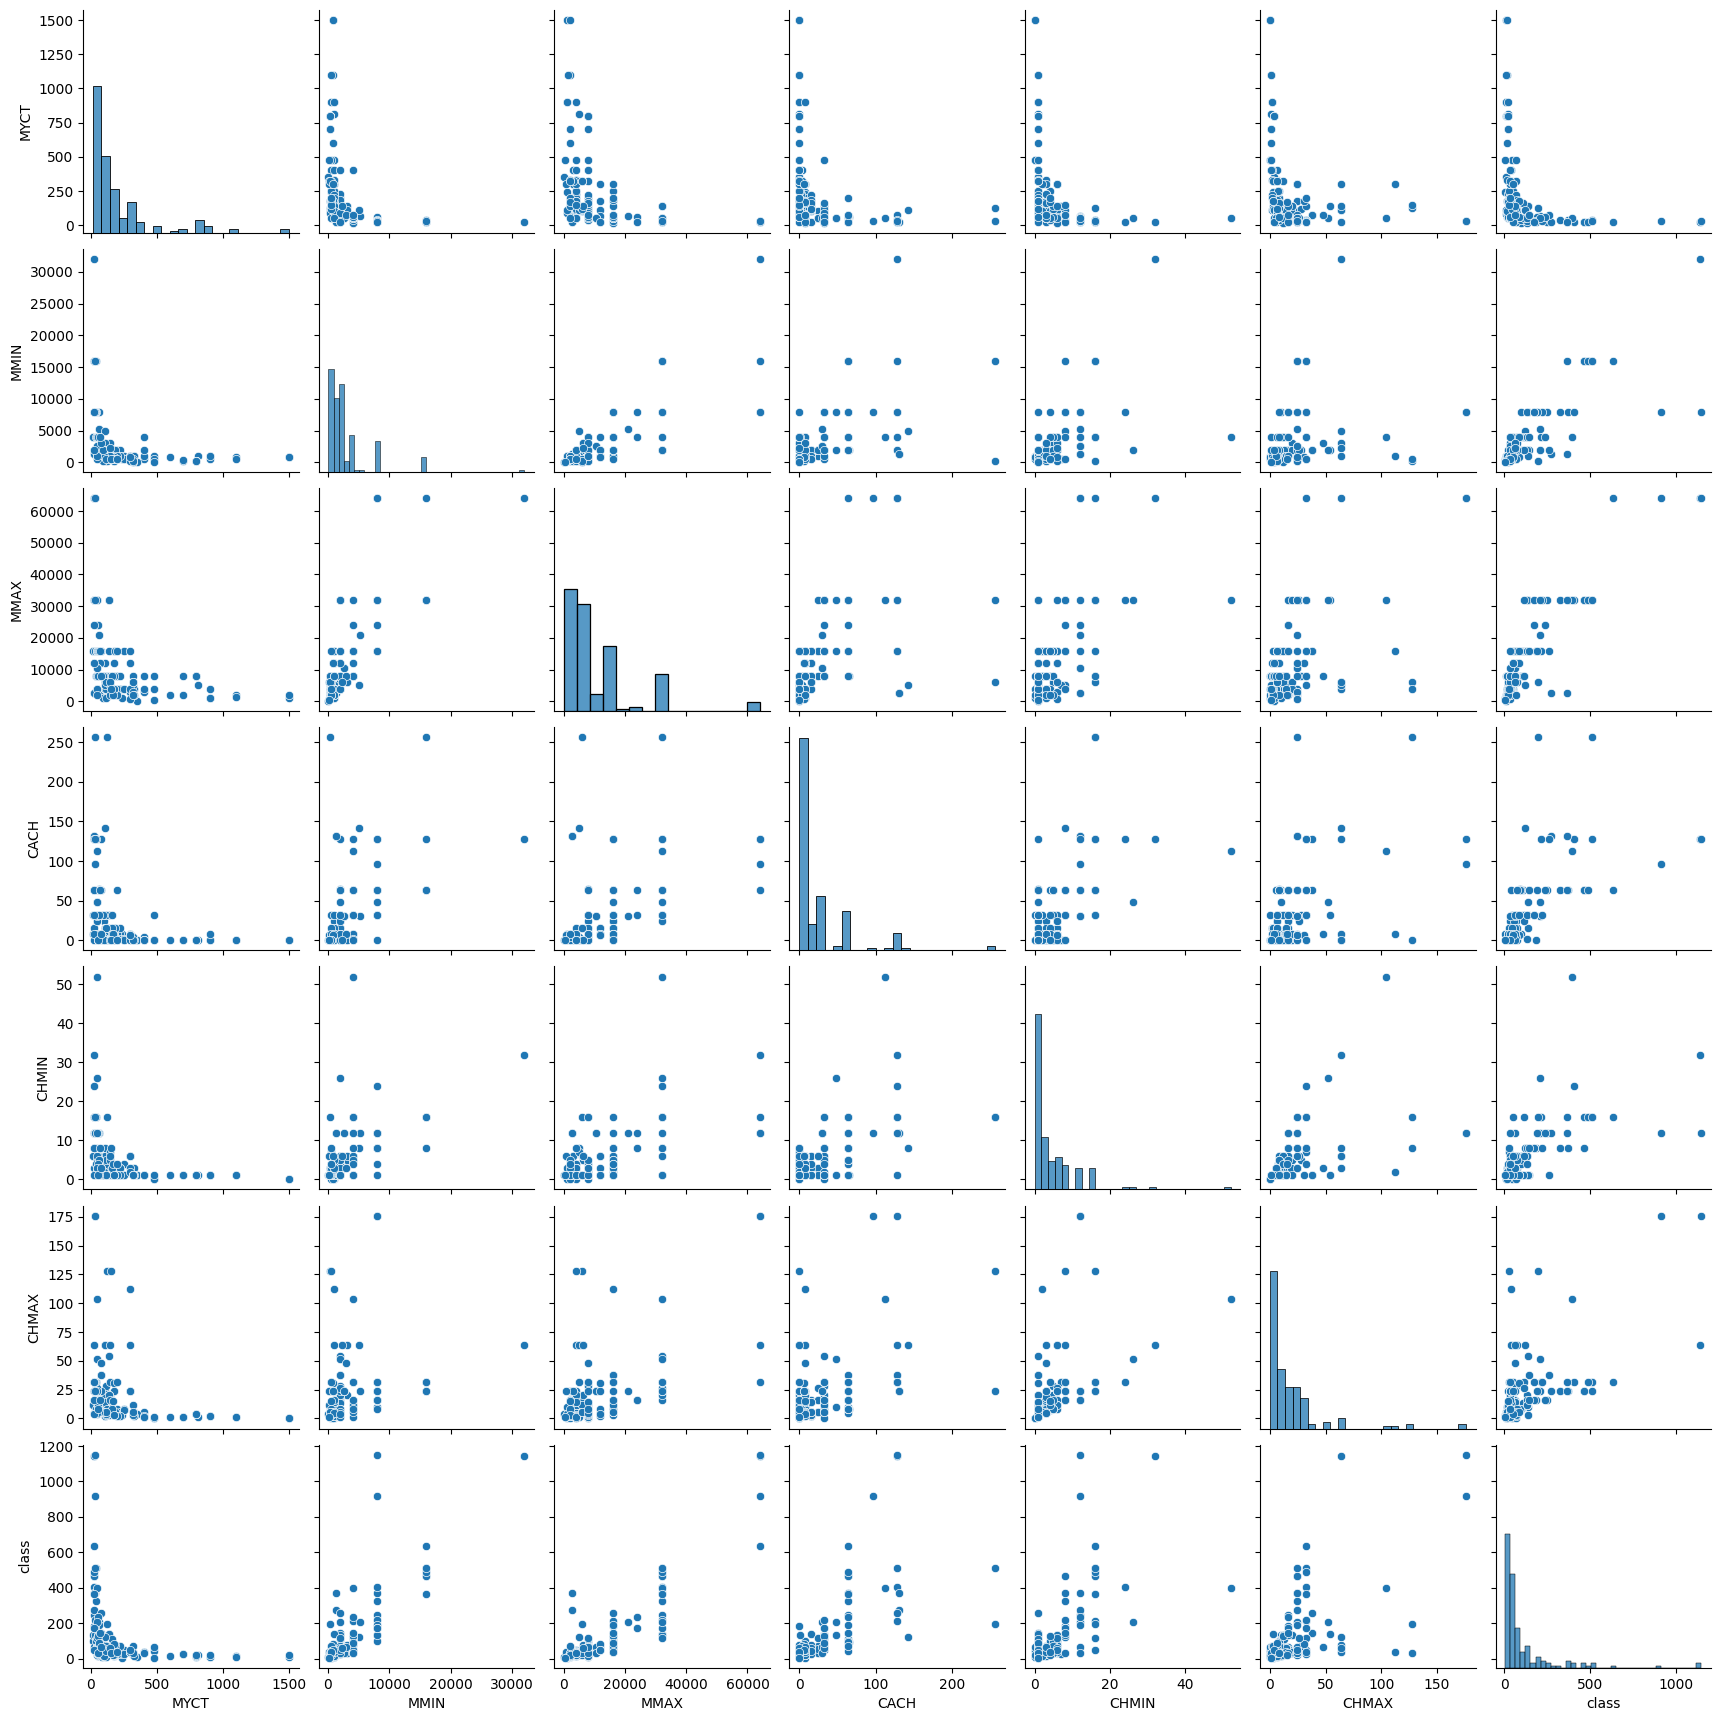

In [ ]:
sns.pairplot(train_data)

In [ ]:
# Перевірка підсумкової статистики
train_data.describe()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,class
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,207.958084,2900.826347,11761.161677,26.071856,4.760479,18.616766,109.185629
std,266.772823,4165.950964,12108.332354,42.410014,6.487439,27.489919,174.061117
min,17.000000,64.000000,64.000000,0.000000,0.000000,0.000000,6.000000
25%,50.000000,768.000000,4000.000000,0.000000,1.000000,5.000000,27.500000
50%,110.000000,2000.000000,8000.000000,8.000000,2.000000,8.000000,50.000000
75%,232.500000,3100.000000,16000.000000,32.000000,6.000000,24.000000,110.000000
max,1500.000000,32000.000000,64000.000000,256.000000,52.000000,176.000000,1150.000000


In [ ]:
# Перевірка відсутніх значень

train_data.isnull().sum()

,0
MYCT,0
MMIN,0
MMAX,0
CACH,0
CHMIN,0
CHMAX,0
class,0


У нас немає відсутніх значень

In [ ]:
# Перевірка кореляції ознак

corr = train_data.corr()
corr['class']

,class
MYCT,-0.301805
MMIN,0.797751
MMAX,0.869077
CACH,0.671581
CHMIN,0.648653
CHMAX,0.606557
class,1.000000


<Axes: >

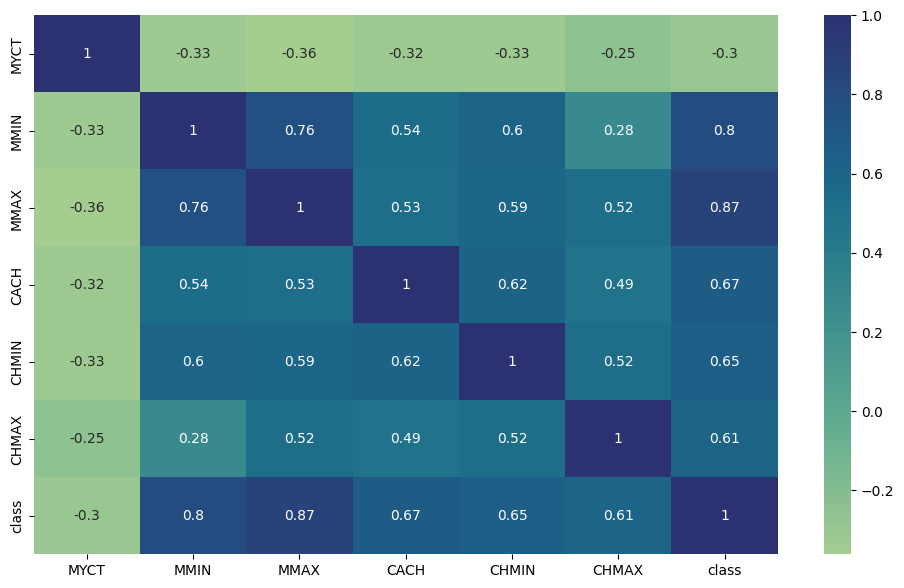

In [ ]:
## Візуалізація кореляції

plt.figure(figsize=(12,7))

sns.heatmap(corr,annot=True,cmap='crest')

<a name='4'></a>

### 4 - Попередня обробка даних

Саме тут ми готуємо дані у належний формат для моделі машинного навчання.

Давайте налаштуємо конвеєр для масштабування функцій, але перед цим візьмемо навчальні вхідні дані та мітки

In [ ]:
X_train = train_data.drop('class', axis=1)
y_train = train_data['class']

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scale_pipe = Pipeline([
    ('scaler', StandardScaler())

])

X_train_scaled = scale_pipe.fit_transform(X_train)

<a name='5'></a>

### 5 - Навчання регресору випадкових *лісів*


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(min_samples_split=2,bootstrap=False, random_state=42,n_jobs=-1)

forest_reg.fit(X_train_scaled, y_train)

RandomForestRegressor(bootstrap=False, n_jobs=-1, random_state=42)

<a name='6'></a>

### 6 - Оцінка регресора випадкових лісів

Давайте спочатку перевіримо середнє квадратичне errr під час навчання. Не рекомендується оцінювати модель на основі тестових даних, оскільки ми її ще не вдосконалили. Ми зробимо функцію, щоб було легше і щоб уникнути повторів

In [ ]:
from sklearn.metrics import mean_squared_error

def predict(input_data,model,labels):
    """
    Візьміть вхідні дані, модель і мітки та поверніть прогнози

    """

    preds = model.predict(input_data)
    mse = mean_squared_error(labels,preds)
    rmse = np.sqrt(mse)
    rmse

    return rmse

In [ ]:
predict(X_train_scaled, forest_reg, y_train)

np.float64(9.724590719956222)

<a name='7'></a>

### 7 - Покращення випадкових лісів

In [ ]:
forest_reg.get_params()

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

Ми використаємо GridSearch, щоб знайти найкращі гіперпараметри, які ми можемо використати для навчання моделі. Якщо встановити для параметра `refit` у `True`, випадковий ліс буде автоматично переналаштовано на набір даних із найкращими гіперпараметрами. За замовчуванням `refit` це True.

Це займе занадто багато часу

In [ ]:
from sklearn.model_selection import GridSearchCV

params_grid = {
    'n_estimators':[100,200,300,400,500],
    'max_leaf_nodes':list(range(0,50))}

#refit за замовчуванням true. Найкращий оцінювач навчається на всьому наборі даних

grid_search = GridSearchCV(RandomForestRegressor(min_samples_split=2,bootstrap=False,random_state=42), params_grid, verbose=1, cv=5)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


GridSearchCV(cv=5,
             estimator=RandomForestRegressor(bootstrap=False, random_state=42),
             param_grid={'max_leaf_nodes': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                            11, 12, 13, 14, 15, 16, 17, 18, 19,
                                            20, 21, 22, 23, 24, 25, 26, 27, 28,
                                            29, ...],
                         'n_estimators': [100, 200, 300, 400, 500]},
             verbose=1)

In [ ]:
grid_search.best_params_

{'max_leaf_nodes': 46, 'n_estimators': 200}

In [ ]:
grid_search.best_estimator_

RandomForestRegressor(bootstrap=False, max_leaf_nodes=46, n_estimators=200,
                      random_state=42)

In [ ]:
forest_best = grid_search.best_estimator_

Давайте знову зробимо прогноз на даних навчання

In [ ]:
predict(X_train_scaled, forest_best, y_train)

np.float64(12.217411163164076)

Дивно, але пошук гіперпараметрів моделі не покращив модель. Чи можете ви здогадатися чому? Є багато речей під час запуску Grid Search та гіперпараметри для випадкових лісів, про що можна прочитати [тут](https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees). Якщо ви не можете отримати хороші результати, встановіть значення`bootstrap` у False. За замовчуванням це вірно, і це означає, що ви тренуєтеся на зразках навчального набору, а не на всьому навчальному наборі. Спробуйте повернутися до оригінальної моделі та змінити її на True і зауважте, як зміниться прогноз

<a name='8'></a>
### 8. Важливість ознак

На відміну від інших моделей машинного навчання, випадкові ліси можуть показати, як кожна ознака сприяла узагальненню моделі. Давайте знайдемо його. Результати – це значення від 0 до 1. Чим ближче до 1, тим хороша ознака була для моделі.

In [ ]:
feat_import = forest_best.feature_importances_

feat_dict ={

    'Features': X_train.columns,
    'Feature Importance': feat_import
}

pd.DataFrame(feat_dict)

,Features,Feature Importance
0,MYCT,0.002990
1,MMIN,0.005777
2,MMAX,0.835472
3,CACH,0.117459
4,CHMIN,0.007567
5,CHMAX,0.030735


Як ви бачите вище, найбільше дві характеристики, які сприяли прогнозу відносної продуктивності процесора `MMAX` це максимальна основна пам’ять у кілобайтах і `CACH` (кеш-пам’ять).

Цілком зрозуміло, що модель змогла це з’ясувати. Основна пам’ять (RAM, постійна пам’ять) і кеш-пам’ять (де зберігається часто використовувана інформація, що сприяє швидшій обробці та швидкому пошуку інформації) є двома основними факторами продуктивності процесора, і якщо ви збираєтеся купити новий комп’ютер, вам потрібно мати великий обсяг оперативної та кеш-пам’яті, щоб мати потужну машину, яка може швидше обробляти/обчислювати та отримувати дані.

<a name='9'></a>
### 9. Оцінка моделі на тестовому наборі

Оцінимо модель на тестовому наборі. Але спочатку запустимо конвеєр на тестових даних. Зауважте, що ми лише перетворюємо (not fit_transform).

In [ ]:
X_test = test_data.drop('class', axis=1)
y_test = test_data['class']

test_scaled = scale_pipe.transform(X_test)

In [ ]:
predict(test_scaled, forest_best, y_test)

np.float64(41.258341325352305)

Результати на тестовому наборі не привабливі, і це ознака того, що модель все ще перенавчена (вона добре працює на навчальному наборі та погано на нових даних). Одним із способів покращити модель може бути регулярізація моделі шляхом пошуку більшої кількості найкращих гіперпараметрів і підвищення даних і якості даних. Останнє – це те, що може покращити модель у багатьох сценаріях

Ми дізналися фундаментальну ідею випадкових лісів і використали її для прогнозування продуктивності ЦП. У наступній частині лабораторній роботі ми використаємо його для завдання класифікації, і ми будемо використовувати реальний набір даних, щоб ми могли практично покращити випадкові ліси

## Випадкови ліси для класифікації

Розглянемо на прикладі класифікації ірисів

### Класифікаційний набір даних: квіти ірису

Давайте тепер подивимося на продуктивність дерев рішень на новому наборі даних Iris flowers.

Це класичний набір даних, спочатку опублікований [R. A. Fisher] (https://en.wikipedia.org/wiki/Ronald_Fisher) у 1936 році. Нині він широко використовується для демонстрації алгоритмів машинного навчання.

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = datasets.load_iris(as_frame=True)

print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
# print part of the dataset
iris_X, iris_y = iris.data, iris.target
pd.concat([iris_X, iris_y], axis=1).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


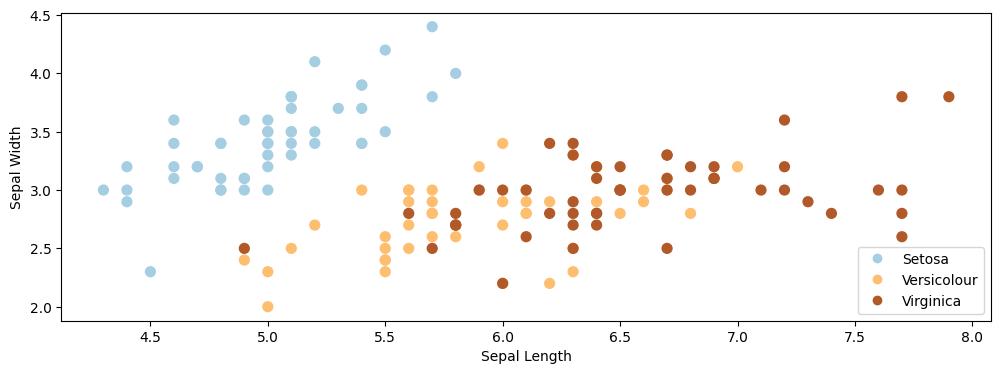

In [ ]:
# Plot also the training points
p1 = plt.scatter(iris_X.iloc[:, 0], iris_X.iloc[:, 1], c=iris_y, s=50, cmap=plt.cm.Paired)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(handles=p1.legend_elements()[0], labels=['Setosa', 'Versicolour', 'Virginica', 'Query'], loc='lower right')

### Дерева рішень на наборі даних Iris flower

Давайте тепер розглянемо, що відбувається, коли ми навчаємо дерево рішень на наборі даних Iris flower.

Наведений нижче код використовуватиметься для візуалізації прогнозів із дерев рішень у цьому наборі даних.

In [ ]:
# https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

def make_grid(X):
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = X.iloc[:, 0].min() - 0.1, X.iloc[:, 0].max() + 0.1
    y_min, y_max = X.iloc[:, 1].min() - 0.1, X.iloc[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    return xx, yy, x_min, x_max, y_min, y_max

def make_2d_preds(clf, X):
    xx, yy, x_min, x_max, y_min, y_max = make_grid(X)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    return Z

def make_2d_plot(ax, Z, X, y):
    # Create color maps
    cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
    cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])

    xx, yy, x_min, x_max, y_min, y_max = make_grid(X)

    # Put the result into a color plot
    ax.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

    # Plot also the training points
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=plt.cm.Paired, edgecolor='k', s=50)
    ax.set_xlabel('Sepal Length')
    ax.set_ylabel('Sepal Width')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

Тепер ми можемо навчити та візуалізувати дерево рішень на цьому наборі даних.

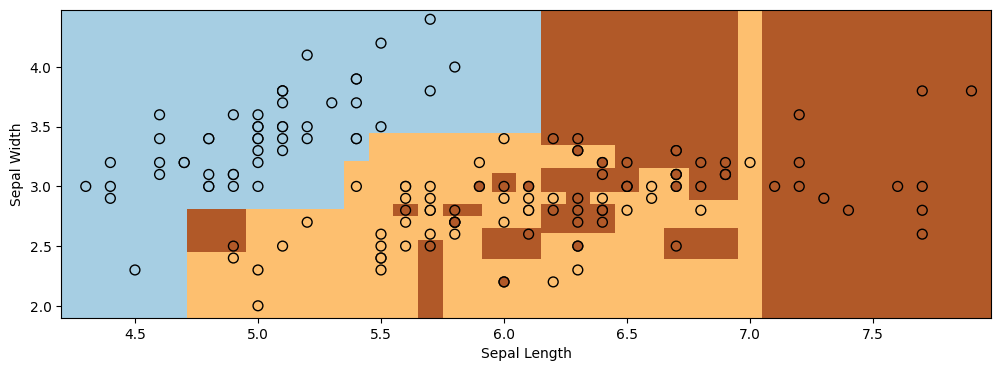

In [ ]:
# Train a Decision Tree Model
ax = plt.gca()
X = iris_X.iloc[:,:2]
clf = DecisionTreeClassifier()
clf.fit(X, iris_y)
Z = make_2d_preds(clf, X)
make_2d_plot(ax, Z, X, iris_y)

### Дві проблеми з деревами рішень

Ми бачимо дві проблеми з виведенням дерева рішень на наборі даних Iris:
* Межа рішення між двома класами є дуже негладкою та блоковою.
* Дерево рішень переповнює дані, а області прийняття рішень сильно фрагментовані.

### Дерева рішень з високою дисперсією

Коли дерева мають достатньо велику глибину, вони можуть швидко переначити дані.

Нагадаємо, що це називається проблемою *високої дисперсії*, оскільки невеликі збурення даних призводять до великих змін у прогнозах моделі.

Розглянемо продуктивність класифікатора дерева рішень на 3 випадкових підмножинах даних.

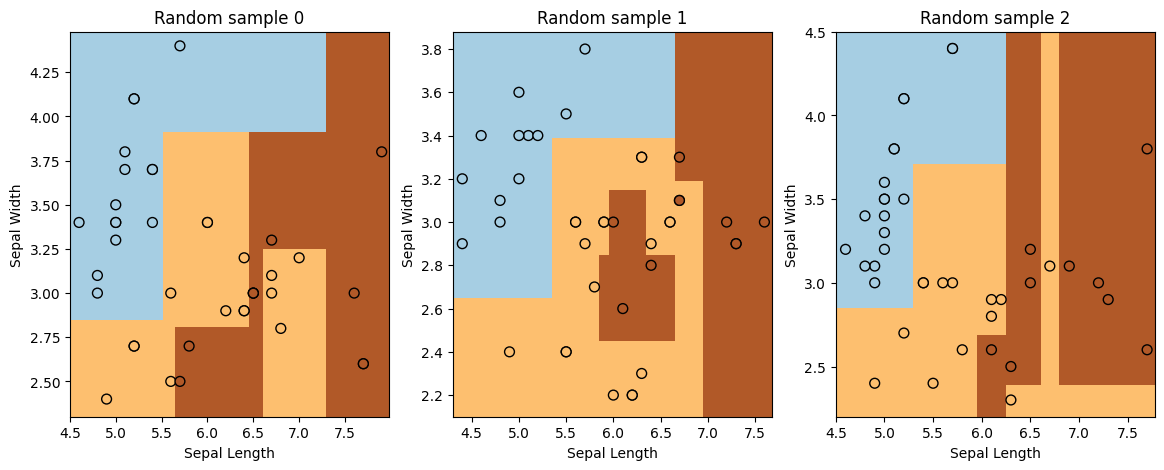

In [ ]:
n_plots, n_flowers, n_samples = 3, iris_X.shape[0], 40
plt.figure(figsize=(14, 5))
for i in range(n_plots):
    ax = plt.subplot(1, n_plots, i + 1)
    random_idx = np.random.randint(0, n_flowers, size=(n_samples,))
    X_random, y_random = iris_X.iloc[random_idx, :2], iris_y[random_idx]

    clf = DecisionTreeClassifier()
    clf.fit(X_random, y_random)
    Z = make_2d_preds(clf, X_random)
    make_2d_plot(ax, Z, X_random, y_random)
    ax.set_title('Random sample %d' % i)

### Застосування випадкового лісу

Щоб зменшити дисперсію основного дерева рішень, ми застосовуємо бегінг — техніку зменшення дисперсії, яку ми бачили раніше.

Ми називаємо дерева рішень з бегінгом *випадковими лісами*.

Встановлюючи наше визначення бегінгу за допомогою дерев рішень, ми отримуємо наступне визначення псевдокоду випадкових лісів:

```python
for i in range(n_models):
    # collect data samples and fit models
    X_i, y_i = sample_with_replacement(X, y, n_samples)
    model = DecisionTree().fit(X_i, y_i)
    random_forest.append(model)

# output average prediction at test time:
y_test = random_forest.average_prediction(y_test)
```

Ми можемо реалізувати випадкові ліси в Python наступним чином:

In [ ]:
np.random.seed(1000)
n_models, n_flowers, n_subset = 300, iris_X.shape[0], 10
random_forest = []
for i in range(n_models):
    # sample the data with replacement
    random_idx = np.random.randint(0, n_flowers, size=(n_subset,))
    X_random, y_random = iris_X.iloc[random_idx, :2], iris_y[random_idx]

    # train a decision tree model
    clf = DecisionTreeClassifier()
    clf.fit(X_random, y_random)

    # append it to our ensemble
    random_forest += [clf]

### Випадкові ліси в наборі даних Flower

Подумайте тепер, що відбувається, коли ми розгортаємо випадкові ліси на тому ж наборі даних, що й раніше.

Тепер кожен прогноз є середнім на наборі пакетних дерев рішень.

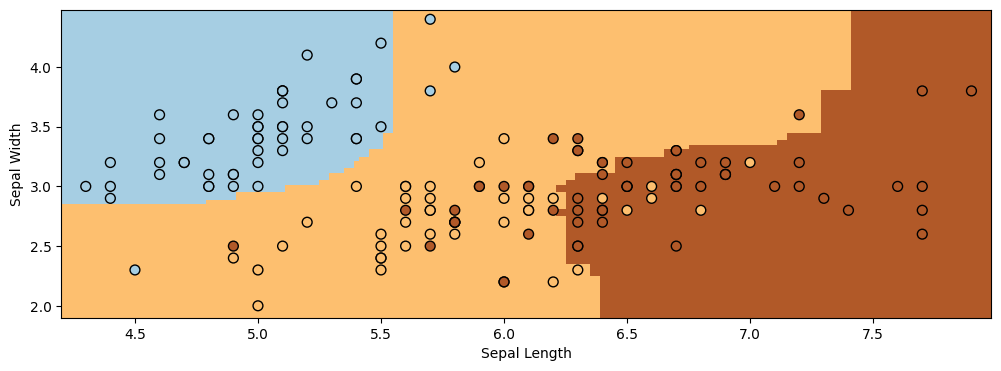

In [ ]:
# Visualize predictions from a random forest
ax = plt.gca()

# compute average predictions from all the models in the ensemble
X_all, y_all = iris_X.iloc[:,:2], iris_y
Z_list = []
for clf in random_forest:
    Z_clf = make_2d_preds(clf, X_all)
    Z_list += [Z_clf]
Z_avg = np.stack(Z_list, axis=2).mean(axis=2)

# visualize predictions
make_2d_plot(ax, np.rint(Z_avg), X_all, y_all)

Межі набагато більш гладкі та добре поводяться.

### Алгоритм: випадкові ліси

* __Тип__: контрольоване навчання (регресія та класифікація).
* __Сімейство моделей__: дерева рішень з бегінгом.
* __Цільова функція__: квадратична помилка, помилка неправильної класифікації, індекс Джіні тощо.
* __Оптимізатор__: жадібне додавання правил з подальшим скороченням

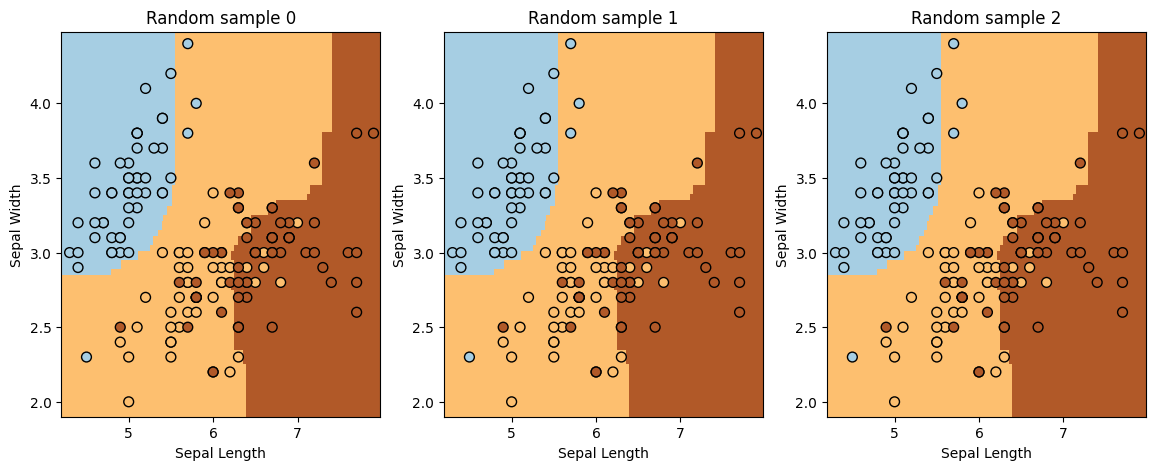

In [ ]:
n_plots, n_flowers, n_samples = 3, iris_X.shape[0], 40
plt.figure(figsize=(14, 5))
X_all, y_all = iris_X.iloc[:,:2], iris_y
for i in range(n_plots):
    ax = plt.subplot(1, n_plots, i + 1)
    random_idx = np.random.randint(0, n_flowers, size=(n_samples,))
    X_random, y_random = X_all.iloc[random_idx, :2], y_all[random_idx]

    Z_list = []
    for clf in random_forest:
        Z_clf = make_2d_preds(clf, X_all)
        Z_list += [Z_clf]
    Z_avg = np.rint(np.stack(Z_list, axis=2).mean(axis=2))

    make_2d_plot(ax, Z_avg, X_all, y_all)
    ax.set_title('Random sample %d' % i)

### Плюси і мінуси випадкових лісів

Випадкові ліси залишаються популярним алгоритмом машинного навчання:

* Вони вимагають невеликої підготовки даних (без масштабування, обробляють безперервні та дискретні ознаки, добре працюють для класифікації та регресії).
* Часто вони досить точні.

Основні їх недоліки полягають у тому, що:
* Вони не підлягають інтерпретації.
* Вони не працюють з неструктурованими даними (зображеннями, аудіо).

# Завдання

### Завдання

Виберить цікавий для себе набір даних з ресурсів, можливо власний набір за напрямом досліджень

https://www.kaggle.com/datasets

https://datasetsearch.research.google.com/

https://www.tensorflow.org/datasets/catalog/overview#all_datasets

https://console.cloud.google.com/marketplace/browse

Вирішить завдання класифікації або регресії за допомогою дерева рішень
* 1 - Імпорт
* 2 - Завантаження даних
* 3 - Дослідницький аналіз
* 4 - Попередня обробка даних
* 5 - Навчання дерева рішень
* 6 - Оцінка дерева рішень
* 7 - Покращення дерева рішень

In [ ]:
# рішення завдання